<a href="https://colab.research.google.com/github/aymuos/endgame/blob/main/00_master_feature_creator.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# LaDe Feature Pipeline — Full Run (Stage 0 → Stage 2)

**Cities:** Shanghai · Hangzhou · Chongqing  
**Target:** `eta_mins = (sign_time − receipt_time) / 60`  
**Author:** Soumya · Thesis: Causal-informed RL for ETA Prediction
** Dataset : ** LaDe https://huggingface.co/datasets/Cainiao-AI/LaDe

---

## Pipeline Architecture

```
Stage 0 ── Data Preparation (this section)
    load d5c_neat.csv (combined 5-city raw data)
    ├─ map Chinese city names → English
    ├─ parse receipt_time / sign_time (prepend "2021-")
    ├─ compute eta_mins ; drop negatives
    ├─ split → shanghai_data.csv, hangzhou_data.csv, chongqing_data.csv
    ├─ identify dropped courier IDs (negative ETA couriers)
    ├─ filter GPS parquet (remove dropped couriers)
    └─ split GPS → {city}_delivery_data.parquet

Stage 1 ── Feature Engineering  (Section 2 onwards)
    per-city: GPS trajectory, batch, workload, spatial, weather, typecode

Stage 2 ── Causal Discovery / RL
    PCMCI+, CD-NOD, ICP/REx, Causal-EXP4
```

## Stage 0 · Data Preparation

Runs once on the raw combined delivery CSV. Outputs are the per-city CSV and GPS parquet files consumed by the feature pipeline in Stage 1.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

BASE_RAW  = '/content/drive/MyDrive/ml/PROCESSED/matched'
CITY_DIR  = BASE_RAW + '/city_divided'

import os
os.makedirs(CITY_DIR, exist_ok=True)

import pandas as pd
import numpy as np


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


### 0.1 Load Combined Dataset

We have 2 sets of data sources:
- delivery level data
- 20s sampled gps data dump

Here we read the cleaned five-city file (`d5c_neat.csv`). which is cleaned and sourced from
(`delivery_five_cities.csv`) directly from the LaDe dataset .

In [ ]:
# wdata = pd.read_csv(BASE_RAW + "/delivery_five_cities.csv")  # original raw
wdata = pd.read_csv(BASE_RAW + "/d5c_neat.csv")  # cleaned for the 3 cities used

print(f"Shape: {wdata.shape}")
print(f"Columns original present : {list(wdata.columns)}")
wdata.head()

Shape: (102183, 15)
Columns original present : ['order_id', 'from_dipan_id', 'from_city_name', 'delivery_user_id', 'poi_lng', 'poi_lat', 'aoi_id', 'typecode', 'receipt_time', 'receipt_lng', 'receipt_lat', 'sign_time', 'sign_lng', 'sign_lat', 'ds']


,order_id,from_dipan_id,from_city_name,delivery_user_id,poi_lng,poi_lat,aoi_id,typecode,receipt_time,receipt_lng,receipt_lat,sign_time,sign_lng,sign_lat,ds
0,55be8cdf1270526231c9ba3387f51b54,c5ac5ba99801aa6b85ba473d9260512b,重庆市,df0b594618d1ba6f619e4e7dd034447c,8.899874e+06,-7.684936e+06,9c0f96ff01a71477334ef563001abc72,203ac3454d75e02ebb0a3c6f51d735e4,03-18 08:32:00,8.900992e+06,-7.686103e+06,03-18 14:33:00,NaN,NaN,318
1,21209805122ad6c7b39c203e77b8d9d8,3dbf3d4ed8dda395a48d49ada37ced6e,杭州市,868a64f65247a5f56490aee6c2eb96a8,1.040387e+07,-7.622290e+06,60a59ad10ca33ebff202c552fae6bfe9,203ac3454d75e02ebb0a3c6f51d735e4,03-18 08:26:00,1.040238e+07,-7.619631e+06,03-18 12:54:00,NaN,NaN,318
2,c00522c5a7072c8788fa9e069f3fe81a,8cde36f7816f76d731e2b3752be837ec,重庆市,be1b1aa5fcd0ee813fa8fe6bca78637e,8.910016e+06,-7.684918e+06,d8fc957cb109c1a0a241954a0c5aa5e2,203ac3454d75e02ebb0a3c6f51d735e4,03-18 07:53:00,8.908245e+06,-7.682531e+06,03-18 10:04:00,NaN,NaN,318
3,030c1387257ebfbbda45b7dea35ff1f8,12fc24c0aa6a27ec0cb3f8bb4d46ec36,重庆市,aba703cad68a631c96aa992d096cbe77,8.903061e+06,-7.676243e+06,5e9a1d1681ace9a86c1bab9c0d1924fc,203ac3454d75e02ebb0a3c6f51d735e4,03-18 07:58:00,8.906168e+06,-7.674608e+06,03-18 11:26:00,NaN,NaN,318
4,8f8a22238f13b4580785e3ad4e1643b6,281a1fe1179fa9099598fc6dcce365cc,上海市,dd648d4143daa61906cdb8c283aedb56,1.053426e+07,-7.479284e+06,fb4b17d3fb592d982bb38d29057baf15,203ac3454d75e02ebb0a3c6f51d735e4,03-18 16:56:00,1.053336e+07,-7.477580e+06,03-18 17:45:00,NaN,NaN,318


---

Columns in gps dump
- ds
- postman_id
- gps_time
- lat
- lng


---


Data in d5c ( original columns )

- order_id → Unique identifier for each package. Use: Links courier events to specific deliveries.

- from_dipan_id : Unique Identifier of the Originating Logistics Station
- city : City name (Shanghai, Hangzhou, etc.)
- delivery_user_id : eSSENTIALLY THE COURIER ID
- poi lng , lat : Customer's location
- aoi_id → Area of Interest ID (e.g., residential complex, office building). Use: Delivery zone granularity. numbers ~ 1700 Thousands of unique IDs per city.
- typecode : tells what kind of place it is , Limited set of standard categories (alpha numeric).
-

- courier_id → Unique identifier for the courier.

- 'lng', 'lat' : Coordinates of each stop in a 2D space (longitude/latitude). Use: Defines delivery/pickup locations.

- receipt_time : Warehourse receipt time
- receipt lat lng : warehouse coordinates
- sign_time : handover time
- sign_lat lng: not given , same as poi
- ds → Date of package delivery MMDD

---

For customer , we have poi lat lng and sign_time

for pickup at warehouse we have
receipt time , receipt lat lng

### 0.2 City Name Mapping + Datetime Parsing

Maps Chinese city names to English and parses the two timestamp columns.
The raw file stores times as `MM-DD HH:MM:SS` strings — "2021-" is prepended
to anchor them to the study year before converting to `datetime64`.

In [ ]:
CITY_MAPPING = {
    '上海市': 'Shanghai',
    '重庆市': 'Chongqing',
    '杭州市': 'Hangzhou',
}

wdata['from_city_en'] = wdata['from_city_name'].map(CITY_MAPPING)
wdata.rename(columns={'from_city_en': 'city'}, inplace=True)
wdata.drop(columns=['from_city_name'], inplace=True)

# Prepend year (data spans Mar–Apr 2021 as per paper)
wdata['receipt_time'] = pd.to_datetime(
    '2021-' + wdata['receipt_time'],
    format='%Y-%m-%d %H:%M:%S'
)
wdata['sign_time'] = pd.to_datetime(
    '2021-' + wdata['sign_time'],
    format='%Y-%m-%d %H:%M:%S'
)

unmapped = wdata['city'].isna().sum()
print(f"Unmapped city rows: {unmapped}")
print(f"Cities found: {wdata['city'].value_counts().to_dict()}")

Unmapped city rows: 0
Cities found: {'Hangzhou': 40774, 'Shanghai': 34736, 'Chongqing': 26673}


In [ ]:
wdata.head()

,order_id,from_dipan_id,delivery_user_id,poi_lng,poi_lat,aoi_id,typecode,receipt_time,receipt_lng,receipt_lat,sign_time,sign_lng,sign_lat,ds,city
0,55be8cdf1270526231c9ba3387f51b54,c5ac5ba99801aa6b85ba473d9260512b,df0b594618d1ba6f619e4e7dd034447c,8.899874e+06,-7.684936e+06,9c0f96ff01a71477334ef563001abc72,203ac3454d75e02ebb0a3c6f51d735e4,2021-03-18 08:32:00,8.900992e+06,-7.686103e+06,2021-03-18 14:33:00,NaN,NaN,318,Chongqing
1,21209805122ad6c7b39c203e77b8d9d8,3dbf3d4ed8dda395a48d49ada37ced6e,868a64f65247a5f56490aee6c2eb96a8,1.040387e+07,-7.622290e+06,60a59ad10ca33ebff202c552fae6bfe9,203ac3454d75e02ebb0a3c6f51d735e4,2021-03-18 08:26:00,1.040238e+07,-7.619631e+06,2021-03-18 12:54:00,NaN,NaN,318,Hangzhou
2,c00522c5a7072c8788fa9e069f3fe81a,8cde36f7816f76d731e2b3752be837ec,be1b1aa5fcd0ee813fa8fe6bca78637e,8.910016e+06,-7.684918e+06,d8fc957cb109c1a0a241954a0c5aa5e2,203ac3454d75e02ebb0a3c6f51d735e4,2021-03-18 07:53:00,8.908245e+06,-7.682531e+06,2021-03-18 10:04:00,NaN,NaN,318,Chongqing
3,030c1387257ebfbbda45b7dea35ff1f8,12fc24c0aa6a27ec0cb3f8bb4d46ec36,aba703cad68a631c96aa992d096cbe77,8.903061e+06,-7.676243e+06,5e9a1d1681ace9a86c1bab9c0d1924fc,203ac3454d75e02ebb0a3c6f51d735e4,2021-03-18 07:58:00,8.906168e+06,-7.674608e+06,2021-03-18 11:26:00,NaN,NaN,318,Chongqing
4,8f8a22238f13b4580785e3ad4e1643b6,281a1fe1179fa9099598fc6dcce365cc,dd648d4143daa61906cdb8c283aedb56,1.053426e+07,-7.479284e+06,fb4b17d3fb592d982bb38d29057baf15,203ac3454d75e02ebb0a3c6f51d735e4,2021-03-18 16:56:00,1.053336e+07,-7.477580e+06,2021-03-18 17:45:00,NaN,NaN,318,Shanghai


### 0.3 Split by City + Compute `eta_mins`

`eta_mins = (sign_time − receipt_time) / 60` in minutes — this becomes

In [ ]:
# storing individual city wise dataframes

shanghai_df  = wdata[wdata['city'] == 'Shanghai'].copy()
chongqing_df = wdata[wdata['city'] == 'Chongqing'].copy()
hangzhou_df  = wdata[wdata['city'] == 'Hangzhou'].copy()

for name, df in [('Shanghai', shanghai_df), ('Chongqing', chongqing_df), ('Hangzhou', hangzhou_df)]:
    df['eta_mins'] = (df['sign_time'] - df['receipt_time']).dt.total_seconds() / 60
    print(f"{name}: {len(df):,} rows | ETA range [{df['eta_mins'].min():.1f}, {df['eta_mins'].max():.1f}] min")

Shanghai: 34,736 rows | ETA range [-4446.0, 16772.0] min
Chongqing: 26,673 rows | ETA range [-6728.0, 31830.0] min
Hangzhou: 40,774 rows | ETA range [-21494.0, 24576.0] min


### 0.4 Remove Negative ETAs + ETA Distribution Diagnostics

Negative ETAs are data entry errors (sign_time < receipt_time).
Percentile diagnostics inform the tier thresholds used in the causal analysis:

- **Shanghai**: 90th pct ≈ 2.87 h, 99th pct ≈ 9.18 h — fast, reliable city
- **Hangzhou**: 90th pct ≈ 4.21 h — intermediate
- **Chongqing**: 90th pct ≈ 8.68 h, 99th pct ≈ 53.43 h — heavy right tail,
  topographic constraints (hilly terrain, river splits)

The KDE peak finder confirms Chongqing's mode at ≈ 2.12 h — unimodal
heavy-tailed (not bimodal; scipy peak detection can produce false peaks
on noisy tails, verified by visual inspection).

In [ ]:
from scipy.stats import gaussian_kde
from scipy.signal import find_peaks

city_dfs = {
    'Shanghai':  shanghai_df,
    'Chongqing': chongqing_df,
    'Hangzhou':  hangzhou_df,
}

for city_name, df in city_dfs.items():
    neg = (df['eta_mins'] < 0).sum()
    print(f"\n--- {city_name} ---")
    print(f"  Negative ETAs: {neg:,}")

city_dfs_clean = {}
for city_name, df in city_dfs.items():
    cleaned = df[df['eta_mins'] >= 0].copy()
    city_dfs_clean[city_name] = cleaned

shanghai_df  = city_dfs_clean['Shanghai']
chongqing_df = city_dfs_clean['Chongqing']
hangzhou_df  = city_dfs_clean['Hangzhou']


--- Shanghai ---
  Negative ETAs: 1

--- Chongqing ---
  Negative ETAs: 3

--- Hangzhou ---
  Negative ETAs: 30


In [ ]:
# ── ETA percentile diagnostics (no plots) ────────────────────────────────────
PERCENTILES = [10, 25, 50, 75, 90, 95, 99]

for city_name, df in city_dfs_clean.items():
    eta_hours = df['eta_mins'] / 60
    eta_clean = eta_hours.dropna()

    print(f"\n--- {city_name} ---")

    # Percentiles
    for p in PERCENTILES:
        print(f"  {p:>2}th pct: {np.percentile(eta_clean, p):.2f} h")

    # KDE peak finding (text output only)
    if len(eta_clean) >= 2:
        x_max = max(eta_clean.quantile(0.99) * 1.5, 10)
        eta_kde = eta_clean[eta_clean < x_max * 1.1]
        kde = gaussian_kde(eta_kde)
        xs  = np.linspace(0, x_max, 1000)
        ys  = kde(xs)
        peaks, _ = find_peaks(ys, height=ys.max() * 0.05)
        if len(peaks):
            locs = [f"{xs[p]:.2f}h" for p in peaks]
            print(f"  KDE peaks: {locs}")
        else:
            print("  KDE peaks: none found")


--- Shanghai ---
  10th pct: 0.38 h
  25th pct: 0.68 h
  50th pct: 1.17 h
  75th pct: 1.90 h
  90th pct: 2.87 h
  95th pct: 3.72 h
  99th pct: 9.18 h
  KDE peaks: ['0.77h']

--- Chongqing ---
  10th pct: 0.60 h
  25th pct: 1.20 h
  50th pct: 2.28 h
  75th pct: 3.98 h
  90th pct: 8.68 h
  95th pct: 12.08 h
  99th pct: 53.43 h
  KDE peaks: ['1.68h', '8.75h']

--- Hangzhou ---
  10th pct: 0.48 h
  25th pct: 0.87 h
  50th pct: 1.52 h
  75th pct: 2.58 h
  90th pct: 4.21 h
  95th pct: 6.68 h
  99th pct: 13.61 h
  KDE peaks: ['0.94h']


### 0.5 Save Per-City Delivery CSVs

Outputs consumed by Stage 1's `load_delivery()`:
`shanghai_data.csv`, `chongqing_data.csv`, `hangzhou_data.csv`

In [ ]:
shanghai_df.to_csv( CITY_DIR + '/shanghai_data.csv',  index=False)
chongqing_df.to_csv(CITY_DIR + '/chongqing_data.csv', index=False)
hangzhou_df.to_csv( CITY_DIR + '/hangzhou_data.csv',  index=False)

for name, df in [('Shanghai', shanghai_df), ('Hangzhou', hangzhou_df), ('Chongqing', chongqing_df)]:
    print(f"  Saved {name}: {len(df):,} rows → {CITY_DIR}/{name.lower()}_data.csv")

  Saved Shanghai: 34,735 rows → /content/drive/MyDrive/ml/PROCESSED/matched/city_divided/shanghai_data.csv
  Saved Hangzhou: 40,744 rows → /content/drive/MyDrive/ml/PROCESSED/matched/city_divided/hangzhou_data.csv
  Saved Chongqing: 26,670 rows → /content/drive/MyDrive/ml/PROCESSED/matched/city_divided/chongqing_data.csv


### 0.6 Identify Dropped Courier IDs

Couriers whose **only** orders had negative ETAs are absent from the cleaned
DataFrames. Their GPS trajectories must also be excluded from the GPS parquet
to keep the delivery and GPS tables consistent.

Summary (study results):  
- Shanghai: 1 dropped courier ID  
- Chongqing: 0  
- Hangzhou: 9  
- GPS rows removed from parquet: ~50,807 / 16,042,735

In [ ]:
# Rebuild original city slices (pre-filter) for ID comparison
for city_name, df in city_dfs.items():
    df['eta_mins'] = (df['sign_time'] - df['receipt_time']).dt.total_seconds() / 60

original_ids = {
    'Shanghai':  set(city_dfs['Shanghai']['delivery_user_id'].unique()),
    'Chongqing': set(city_dfs['Chongqing']['delivery_user_id'].unique()),
    'Hangzhou':  set(city_dfs['Hangzhou']['delivery_user_id'].unique()),
}
filtered_ids = {
    'Shanghai':  set(shanghai_df['delivery_user_id'].unique()),
    'Chongqing': set(chongqing_df['delivery_user_id'].unique()),
    'Hangzhou':  set(hangzhou_df['delivery_user_id'].unique()),
}

dropped_ids = {}
all_dropped = set()
for city in ['Shanghai', 'Chongqing', 'Hangzhou']:
    dropped = original_ids[city] - filtered_ids[city]
    dropped_ids[city] = dropped
    all_dropped |= dropped
    print(f"  {city}: {len(dropped)} dropped courier ID(s)")

print(f"\n  Total unique dropped IDs: {len(all_dropped)}")

  Shanghai: 1 dropped courier ID(s)
  Chongqing: 0 dropped courier ID(s)
  Hangzhou: 9 dropped courier ID(s)

  Total unique dropped IDs: 10


### 0.7 Filter GPS Parquet + Split by City

Removes dropped courier rows from the full GPS parquet, then splits by city
using the delivery CSVs' `delivery_user_id` sets.

Output files consumed by Stage 1's `load_gps_window()`:
`{city}_delivery_data.parquet`

In [ ]:
GPS_PARQUET = BASE_RAW + '/tj_processed_join_filtered.parquet'
GPS_FILTERED_OUT = BASE_RAW + '/tj_process_negative_removed.parquet'

parquet_df = pd.read_parquet(GPS_PARQUET)
print(f"GPS parquet shape (before filter): {parquet_df.shape}")

# Remove rows for dropped couriers
parquet_df_filtered = parquet_df[~parquet_df['postman_id'].isin(all_dropped)].copy()
print(f"GPS parquet shape (after filter):  {parquet_df_filtered.shape}")
print(f"Rows removed: {len(parquet_df) - len(parquet_df_filtered):,}")

parquet_df_filtered.to_parquet(GPS_FILTERED_OUT, index=False)
print(f"\nSaved filtered GPS parquet → {GPS_FILTERED_OUT}")

GPS parquet shape (before filter): (16042735, 5)
GPS parquet shape (after filter):  (15991938, 5)
Rows removed: 50,797

Saved filtered GPS parquet → /content/drive/MyDrive/ml/PROCESSED/matched/tj_process_negative_removed.parquet


In [ ]:
# ── Split GPS parquet by city using delivery_user_id sets ─────────────────────
city_delivery_ids = {
    'shanghai':  set(shanghai_df['delivery_user_id'].unique()),
    'chongqing': set(chongqing_df['delivery_user_id'].unique()),
    'hangzhou':  set(hangzhou_df['delivery_user_id'].unique()),
}

for slug, ids in city_delivery_ids.items():
    city_gps = parquet_df_filtered[
        parquet_df_filtered['postman_id'].isin(ids)
    ].copy()

    out_path = f"{CITY_DIR}/{slug}_delivery_data.parquet"
    city_gps.to_parquet(out_path, index=False)
    print(f"  {slug.capitalize()} GPS: {city_gps.shape[0]:,} rows → {out_path}")

print("\n✅ Stage 0 complete — all city files ready for Stage 1.")

  Shanghai GPS: 3,592,545 rows → /content/drive/MyDrive/ml/PROCESSED/matched/city_divided/shanghai_delivery_data.parquet
  Chongqing GPS: 4,914,746 rows → /content/drive/MyDrive/ml/PROCESSED/matched/city_divided/chongqing_delivery_data.parquet
  Hangzhou GPS: 7,484,647 rows → /content/drive/MyDrive/ml/PROCESSED/matched/city_divided/hangzhou_delivery_data.parquet

✅ Stage 0 complete — all city files ready for Stage 1.


---

## Stage 1 · Feature Engineering

All cells below are the feature engineering pipeline run per city .
Inputs are the per-city CSV and GPS parquet files produced in Stage 0 above.

In [ ]:
!pip install duckdb polars pyarrow --quiet

In [ ]:
import polars as pl
import duckdb
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from datetime import date

pl.Config.set_tbl_rows(10)
print("Polars:", pl.__version__, " | DuckDB:", duckdb.__version__)

Polars: 1.35.2  | DuckDB: 1.3.2


## Pipeline Overview

```
load_delivery()
add_euclidean_distance()
add_batch_features()
add_workload_causal()
    └─ compute_speed_percentile()
        └─ compute_trajectory_features()
add_operational_and_distance_features()
add_temporal_features()
add_gps_missingness_flag()
add_typecode_encoding()
add_spatial_congestion_v2()
add_weather()
```

Each section below is a reusable function. The **Run All Cities** section
loops over all three cities and saves per-city parquets plus a combined parquet.

## 0. Install & Imports

### Delivery level feature engineering

## 1. Configuration

Edit paths and parameters below before running.

- **`CITY_CONFIGS`** — add/remove cities here; each entry carries its own file names,
  weather CSV path, and holiday list so the pipeline is fully self-contained per city.
- **`PRE_MIN`** — GPS look-back window (minutes before `receipt_time`).
- **`MAX_GAP`** — GPS matches older than this are invalidated as stale.
- **`GRID_SIZE`** — spatial grid cell size in affine coordinate units (≈ 500 m).
- **`WORKLOAD_CAP`** — cap applied in `add_workload_nonlinear` to suppress extreme outliers.
- **`ROLLING_DAYS`** — reserved for future rolling-window features.

In [ ]:
# ── Paths ─────────────────────────────────────────────────────────────────────
BASE         = "/content/drive/MyDrive/ml/PROCESSED/matched/city_divided/"
WEATHER_BASE = "/content/drive/MyDrive/ml/weather-outputs/"
OUTPUT_DIR   = "/content/drive/MyDrive/ml/CORRECTEDv3/"
Path(OUTPUT_DIR).mkdir(parents=True, exist_ok=True)

# ── Pipeline hyper-parameters ─────────────────────────────────────────────────
PRE_MIN      = 15     # minutes of GPS history before receipt_time
MAX_GAP      = 30     # GPS staleness threshold (minutes)
GRID_SIZE    = 500    # spatial grid cell size (affine coordinate units ≈ 500 m)
WORKLOAD_CAP = 20     # workload cap for non-linear features
ROLLING_DAYS = 7      # reserved for future rolling-window features

# ── City registry ─────────────────────────────────────────────────────────────
# Each entry:
#   city_en       : human-readable name (must match CITY_IN_QUES in weather CSVs)
#   delivery_file : CSV filename under BASE
#   gps_file      : parquet filename under BASE
#   weather_file  : CSV filename under WEATHER_BASE
#   holidays      : list of 'YYYY-MM-DD' strings (Qingming Festival 2021)
#   holiday_eve   : day before first holiday
CITY_CONFIGS = [
    {
        "city_en"      : "Shanghai",
        "delivery_file": "shanghai_data.csv",
        "gps_file"     : "shanghai_delivery_data.parquet",
        "weather_file" : "shanghai_wsi_mar17_apr20_2021.csv",
        "holidays"     : ["2021-04-03", "2021-04-04", "2021-04-05"],
        "holiday_eve"  : "2021-04-02",
    },
    {
        "city_en"      : "Hangzhou",
        "delivery_file": "hangzhou_data.csv",
        "gps_file"     : "hangzhou_delivery_data.parquet",
        "weather_file" : "hangzhou_wsi_mar17_apr20_2021.csv",
        "holidays"     : ["2021-04-03", "2021-04-04", "2021-04-05"],
        "holiday_eve"  : "2021-04-02",
    },
    {
        "city_en"      : "Chongqing",
        "delivery_file": "chongqing_data.csv",
        "gps_file"     : "chongqing_delivery_data.parquet",
        "weather_file" : "chongqing_wsi_mar17_apr20_2021.csv",
        "holidays"     : ["2021-04-03", "2021-04-04", "2021-04-05"],
        "holiday_eve"  : "2021-04-02",
    },
]



In [ ]:
# ── Selected features for downstream causal / RL stages ──────────────────────
SELECTED_FEATURES = [
    "order_id", "city", "batch_id",
    "batch_size", "batch_rank_dispatch", "batch_rank_actual",
    "workload_causal", "delivery_sequence_daily",
    "speed_mean", "distance_travelled", "gps_points", "gps_gap_min",
    "is_trajectory_available",
    "pickup_destination_distance",
    "hour_sin", "hour_cos", "day_sin", "day_cos",
    "is_holiday", "is_holiday_eve", "is_weekend",
    "WSI", "precipitation", "temperature_2m", "windspeed_10m",
    "typecode_grouped_type 1", "typecode_grouped_type 2",
    "typecode_grouped_type 3", "typecode_cb",
    "spatial_congestion_daily", "spatial_congestion_norm",
    "courier_local_load",
    "eta_mins",
]

## 2. Pipeline Functions

All transformation logic lives here.  Functions are **stateless** — they receive a
dataframe (and sometimes a DuckDB connection / path) and return a new dataframe.
No global mutation.

---

# Engineered Feature buckets

* ### Structural features
-

---
* ### Operational state features
-

---
* ### Environmental features
-

---
* ### Temporal Control Variables
-
---

* ### Diagonistic / Post Adhoc features
-

### 2.1 `load_delivery` — Load, normalise, and filter the delivery CSV

**ETA filter :** rows with `eta_mins ≤ 0` or `≥ 1440` are dropped.
- `eta ≤ 0` — data entry errors; a negative delivery time is physically impossible.
- `eta ≥ 1440` — exceeds 24 h; almost certainly warehousing delays or GPS silence
  rather than active last-mile delivery (confirmed via percentile based ETA long-tail analysis).

In [ ]:
# def load_delivery(csv_path: str) -> pl.DataFrame:
#     """
#     Load the city delivery CSV, parse datetimes, apply ETA validity filter,
#     drop redundant columns, rename the target variable, and sort for
#     downstream ASOF joins.

#     ETA filter: 0 < eta_mins < 1440 (drops noise and warehousing artefacts).

#     Returns
#     -------
#     pl.DataFrame  sorted by (delivery_user_id, receipt_time)
#     """
#     df = (
#         pl.read_csv(csv_path)
#         .with_columns([
#             pl.col("receipt_time").str.to_datetime("%Y-%m-%d %H:%M:%S"),
#             pl.col("sign_time").str.to_datetime("%Y-%m-%d %H:%M:%S"),
#         ])
#         .drop(["sign_lat", "sign_lng"])          # redundant destination cols
#         .with_columns(pl.col("delivery_user_id").cast(pl.Utf8))
#     )

#     # v2: validity filter
#     before = df.height
#     df = df.filter(
#         (pl.col("eta_mins") > 0) &
#         (pl.col("eta_mins") < 1440)
#     )
#     dropped = before - df.height
#     if dropped > 0:
#         print(f"  ETA filter dropped {dropped:,} rows ({dropped/before*100:.2f}%)")

#     df = df.sort(["delivery_user_id", "receipt_time"])
#     print(f"  Loaded {df.height:,} deliveries | {df['delivery_user_id'].n_unique()} couriers")
#     return df

### 2.2 `load_gps_window` — Fetch relevant GPS records via DuckDB

Uses DuckDB push-down filtering to avoid loading the full GPS parquet into memory.
Only couriers active during the delivery window (±`pre_min` minutes) are pulled.

In [ ]:
# def load_gps_window(
#     con: duckdb.DuckDBPyConnection,
#     gps_path: str,
#     couriers: list,
#     start_time,
#     end_time,
#     pre_min: int = PRE_MIN,
# ) -> pl.DataFrame:
#     """
#     Pull GPS rows for the relevant couriers and time range from parquet.
#     Uses DuckDB for push-down filtering — avoids loading the full GPS file.

#     Returns
#     -------
#     pl.DataFrame  columns: delivery_user_id, gps_time, lat, lng
#                   sorted by (delivery_user_id, gps_time)
#     """
#     # DuckDB requires a tuple with ≥ 2 elements for the IN clause
#     couriers_tuple = tuple(couriers) if len(couriers) > 1 else (couriers[0], couriers[0])

#     gps_df = con.execute(f"""
#         SELECT postman_id, gps_time, lat, lng
#         FROM parquet_scan('{gps_path}')
#         WHERE postman_id IN {couriers_tuple}
#           AND gps_time BETWEEN
#               TIMESTAMP '{start_time}' - INTERVAL '{pre_min} minutes'
#               AND TIMESTAMP '{end_time}'
#     """).pl()

#     gps_df = (
#         gps_df
#         .rename({"postman_id": "delivery_user_id"})
#         .sort(["delivery_user_id", "gps_time"])
#     )
#     print(f"  GPS rows loaded: {gps_df.height:,}")
#     return gps_df

### 2.3 `courier_snapshot` + `filter_stale_gps` — Last known position

ASOF backward join attaches the courier's most recent GPS ping at or before each
`receipt_time`. Pings older than `max_gap` minutes are then nulled out — stale GPS
is operationally unreliable and structurally different from observed zero-speed
movement (indoor delivery, urban canyon signal loss, device quality).

In [ ]:
# def courier_snapshot(delivery: pl.DataFrame, gps_df: pl.DataFrame) -> pl.DataFrame:
#     """
#     ASOF backward join: for each receipt_time, attach the courier's most recent
#     GPS point at or before that moment.

#     Returns
#     -------
#     pl.DataFrame  delivery + last_x, last_y, last_gps_time, gps_gap_min
#     """
#     state = delivery.join_asof(
#         gps_df,
#         left_on="receipt_time",
#         right_on="gps_time",
#         by="delivery_user_id",
#         strategy="backward",
#     ).rename({"lat": "last_x", "lng": "last_y", "gps_time": "last_gps_time"})

#     state = state.with_columns(
#         (pl.col("receipt_time") - pl.col("last_gps_time"))
#         .dt.total_minutes()
#         .alias("gps_gap_min")
#     )
#     return state


# def filter_stale_gps(state: pl.DataFrame, max_gap: int = MAX_GAP) -> pl.DataFrame:
#     """
#     Invalidate GPS matches older than max_gap minutes.
#     Sets gps_gap_min, last_x, last_y to null for stale matches.

#     Rationale: GPS older than 30 min is operationally unreliable; treating it
#     as missing is safer than propagating stale location estimates.

#     Returns
#     -------
#     pl.DataFrame  state with stale GPS columns nulled out
#     """
#     state = state.with_columns(
#         pl.when(pl.col("gps_gap_min") <= max_gap)
#           .then(pl.col("gps_gap_min"))
#           .otherwise(None)
#           .alias("gps_gap_min")
#     )
#     state = state.with_columns([
#         pl.when(pl.col("gps_gap_min").is_null()).then(None).otherwise(pl.col("last_x")).alias("last_x"),
#         pl.when(pl.col("gps_gap_min").is_null()).then(None).otherwise(pl.col("last_y")).alias("last_y"),
#     ])

#     total   = state.height
#     missing = state["gps_gap_min"].null_count()
#     print(f"  GPS coverage after {max_gap}-min filter: "
#           f"{total - missing:,}/{total:,} ({(total-missing)/total*100:.1f}%)")
#     return state

### 2.4 `compute_speed_percentile` — 99th-percentile speed cap

A robust speed ceiling computed from the full GPS parquet.  
Filters: `dt > 5 s` (removes GPS duplicates), `dt < 600 s` (removes long gaps),
`dist < 10000` (removes privacy-related coordinate jumps).

In [ ]:
# def compute_speed_percentile(
#     con: duckdb.DuckDBPyConnection,
#     gps_path: str,
#     percentile: float = 0.99,
# ) -> float:
#     """
#     Compute a robust speed cap from the full GPS parquet.

#     Filters:
#       dt > 5 s    — removes GPS duplicates (sampling ≈ 20 s)
#       dt < 600 s  — removes long gaps that create phantom distance
#       dist < 10000 — removes privacy-related coordinate jumps

#     Returns
#     -------
#     float  speed threshold in affine coordinate units / second
#     """
#     speed_q = con.execute(f"""
#         WITH motion AS (
#             SELECT
#                 SQRT(POWER(lat - LAG(lat) OVER w, 2) +
#                      POWER(lng - LAG(lng) OVER w, 2)) AS dist,
#                 EXTRACT(EPOCH FROM (gps_time - LAG(gps_time) OVER w)) AS dt
#             FROM parquet_scan('{gps_path}')
#             WINDOW w AS (PARTITION BY postman_id ORDER BY gps_time)
#         ),
#         clean AS (
#             SELECT dist / dt AS speed
#             FROM motion
#             WHERE dt > 5 AND dt < 600 AND dist < 10000
#         )
#         SELECT quantile_cont(speed, {percentile}) FROM clean
#     """).fetchone()[0]

#     print(f"  Speed {percentile*100:.0f}th percentile cap: {speed_q:.4f} units/s")
#     return speed_q

### 2.5 `compute_trajectory_features` — 15-min pre-delivery GPS window

Aggregates GPS segments in `[receipt_time − pre_min, receipt_time]` per order.
Speed filtering (per segment): removes GPS duplicates (`dt ≤ 1 s`), privacy jumps
(`dist > 5000`), and physically impossible speeds (above 99th-percentile cap).

In [ ]:
# def compute_trajectory_features(con, gps_path, speed_cap, pre_min=15):
#     """
#     Enhanced Trajectory Features:
#     - speed_mean/std
#     - idle_fraction: % of time speed < 0.1 units/s
#     - coverage_ratio: % of the 15m window where GPS points are present
#     - distance_travelled
#     """
#     traj = con.execute(f"""
#         WITH gps_window AS (
#             SELECT
#                 d.order_id, g.gps_time, g.lat, g.lng,
#                 LAG(g.lat) OVER (PARTITION BY d.order_id ORDER BY g.gps_time) AS prev_lat,
#                 LAG(g.lng) OVER (PARTITION BY d.order_id ORDER BY g.gps_time) AS prev_lng,
#                 LAG(g.gps_time) OVER (PARTITION BY d.order_id ORDER BY g.gps_time) AS prev_time
#             FROM delivery_tbl d
#             JOIN parquet_scan('{gps_path}') g ON g.postman_id = d.delivery_user_id
#             WHERE g.gps_time BETWEEN d.receipt_time - INTERVAL '{pre_min} minutes' AND d.receipt_time
#         ),
#         motion AS (
#             SELECT order_id,
#                    SQRT(POWER(lat - prev_lat, 2) + POWER(lng - prev_lng, 2)) AS dist,
#                    EXTRACT(EPOCH FROM (gps_time - prev_time)) AS dt
#             FROM gps_window
#         ),
#         speed_calc AS (
#             SELECT order_id, dist, dt,
#                    CASE WHEN dt > 1 AND dist < 5000 AND (dist/dt) <= {speed_cap} THEN dist/dt ELSE NULL END AS speed
#             FROM motion
#         )
#         SELECT
#             order_id,
#             COUNT(*) AS gps_points,
#             AVG(speed) AS speed_mean_15m,
#             STDDEV(speed) AS speed_std_15m,
#             SUM(dist) AS distance_travelled_15m,
#             COUNT(CASE WHEN speed < 0.1 THEN 1 END) * 1.0 / COUNT(*) AS idle_fraction,
#             COUNT(*) * 1.0 / ({pre_min} * 3) AS coverage_ratio -- Approx ratio assuming 20s sampling
#         FROM speed_calc
#         GROUP BY order_id
#     """).pl()
#     return traj

### 2.7 `add_batch_features` — Batch size, dispatch rank, actual rank, batch ID


| Column | Definition | Causal role |
|---|---|---|
| `batch_rank_dispatch` | Order within simultaneous push (sorted by `order_id`) — deterministic, reproducible | Pre-delivery operational context |
| `batch_rank_actual` | Rank by `sign_time` within the batch — post-hoc delivery sequence | Observed service order; do **not** use as a predictor (data leakage from target) |
| `batch_id` | `delivery_user_id + "__" + epoch(receipt_time)` — explicit batch key | Enables batch-level aggregation without re-grouping |

`batch_rank_actual` is stored for analysis only. Use `batch_rank_dispatch` in models.

In [ ]:
# def add_batch_features(delivery: pl.DataFrame) -> pl.DataFrame:
#     """
#     Compute batch_size, batch_rank_dispatch, batch_rank_actual, and batch_id.

#     Batch = set of orders sharing the same (delivery_user_id, receipt_time).

#     batch_rank_dispatch: position within the simultaneous dispatcher push.
#         order_id is the tiebreaker — deterministic, reproducible, free of leakage.
#     batch_rank_actual:   rank by sign_time within the batch (post-hoc).
#         Stored for analysis; DO NOT use as a model feature (target leakage).
#     batch_id:            explicit compound key for batch-level joins.

#     Adds columns: batch_size, batch_rank_dispatch, batch_rank_actual, batch_id
#     """
#     delivery = delivery.sort(["delivery_user_id", "receipt_time", "order_id"])

#     # Batch size
#     delivery = delivery.with_columns(
#         pl.len().over(["delivery_user_id", "receipt_time"]).alias("batch_size")
#     )

#     # Dispatch rank (pre-delivery order — safe for modelling)
#     delivery = delivery.with_columns(
#         pl.int_range(0, pl.len())
#           .over(["delivery_user_id", "receipt_time"])
#           .alias("batch_rank_dispatch")
#     )

#     # Actual delivery rank (post-hoc — for analysis only)
#     delivery = delivery.with_columns(
#         (
#             pl.col("sign_time")
#             .rank("ordinal")
#             .over(["delivery_user_id", "receipt_time"]) - 1
#         ).alias("batch_rank_actual")
#     )

#     # Explicit batch identifier
#     delivery = delivery.with_columns(
#         (
#             pl.col("delivery_user_id") + "__" +
#             pl.col("receipt_time").dt.epoch("s").cast(pl.Utf8)
#         ).alias("batch_id")
#     )

#     n_batched = delivery.filter(pl.col("batch_size") > 1).height
#     print(f"  Orders in multi-order batches: {n_batched:,} "
#           f"| max batch_size: {delivery['batch_size'].max()}")
#     return delivery

### 2.8 `add_workload_causal` — Concurrent active orders (event-sweep)

Linear-time event-sweep algorithm (O(n log n) sort + O(n) scan) — avoids
the O(n²) self-join. Result stored as **`workload_causal`** (v2 naming).

**Priority logic:** end events (`priority=2`) sort *after* start events (`priority=1`)
at equal timestamps, so a completion at time T does not reduce the count for an order
received at the same T. This preserves the causal ordering: the new receipt observes
the queue *before* any concurrent sign-off is processed.

In [ ]:
# def add_workload_causal(delivery: pl.DataFrame) -> pl.DataFrame:
#     """
#     Compute active_orders at each receipt_time via a linear-time event-sweep.

#     Why not self-join?  A self-join is O(n²) — prohibitive at 40k+ orders.

#     Algorithm:
#         start_events (+1, priority=1) at receipt_time
#         end_events   (-1, priority=2) at sign_time   [resolve AFTER receipts]
#         cumsum(delta) over (courier, time, priority) → active_orders
#         ASOF join back to delivery on receipt_time → subtract self-count

#     Priority 2 for end events (v2): ensures a sign-off at the same timestamp
#     as a new receipt does not reduce the queue count for that receipt.

#     Adds column: workload_causal
#     """
#     delivery = delivery.sort(["delivery_user_id", "receipt_time"])

#     start_events = delivery.select([
#         "delivery_user_id",
#         pl.col("receipt_time").alias("time"),
#         pl.lit(1).alias("delta"),
#         pl.lit(1).alias("priority"),
#     ])
#     end_events = delivery.select([
#         "delivery_user_id",
#         pl.col("sign_time").alias("time"),
#         pl.lit(-1).alias("delta"),
#         pl.lit(2).alias("priority"),   # sign events resolve AFTER receipts
#     ])

#     events = (
#         pl.concat([start_events, end_events])
#         .sort(["delivery_user_id", "time", "priority"])
#         .with_columns(
#             pl.col("delta").cum_sum().over("delivery_user_id").alias("active_orders")
#         )
#     )

#     workload = delivery.join_asof(
#         events.select(["delivery_user_id", "time", "active_orders"]),
#         left_on="receipt_time",
#         right_on="time",
#         by="delivery_user_id",
#         strategy="backward",
#     )

#     # Subtract self — the current order is already counted in the sweep
#     workload = workload.with_columns(
#         (pl.col("active_orders") - 1).clip(lower_bound=0)
#         .alias("workload_causal")
#     )

#     print(f"  workload_causal | mean: {workload['workload_causal'].mean():.2f} "
#           f"| max: {workload['workload_causal'].max()}")
#     return workload

In [ ]:
# def add_operational_and_distance_features(df, speed_cap):
#     # 1. Courier EWM ETA (History of performance)
#     df = df.sort(["delivery_user_id", "receipt_time"])
#     df = df.with_columns(
#         pl.col("eta_mins").ewm_mean(half_life=10).over("delivery_user_id").shift(1).alias("courier_eta_ewm")
#     )

#     # 2. Remaining Haul Distance (Sum of distances to all future stops in current batch)
#     df = df.sort(["batch_id", "batch_rank_actual"])
#     df = df.with_columns([
#         pl.col("pickup_destination_distance").reverse().cum_sum().over("batch_id").reverse().alias("remaining_haul_distance")
#     ])

#     # 3. Batch size flag
#     df = df.with_columns((pl.col("batch_size") > 1).cast(pl.Int8).alias("batch_size_flag"))

#     return df

### 2.9 `add_temporal_features` — Cyclical time + calendar flags

Cyclical encoding preserves the circular topology of time (avoids the 23→0
discontinuity). **v2 change:** `delivery_sequence_daily` resets per courier per day
instead of accumulating over the full dataset — removes spurious multi-day drift
that would confound causal analysis across the study window.

In [ ]:
# def add_temporal_features(
#     features: pl.DataFrame,
#     holidays: list,
#     holiday_eve: str,
# ) -> pl.DataFrame:
#     """
#     Adds time-of-day and calendar context features.

#     Cyclical encoding: sin/cos(2π × hour / 24) — avoids the 23→0 discontinuity.

#     Adds columns:
#         hour, weekday, receipt_date, day_of_week
#         hour_sin, hour_cos, day_sin, day_cos
#         is_weekend, is_holiday, is_holiday_eve
#         delivery_sequence_daily  (cumulative per courier per day — fatigue proxy,
#                                   resets at midnight to avoid multi-day drift)
#     """
#     features = features.with_columns([
#         pl.col("receipt_time").dt.hour().alias("hour"),
#         pl.col("receipt_time").dt.weekday().alias("weekday"),
#         pl.col("receipt_time").dt.date().alias("receipt_date"),
#         pl.col("receipt_time").dt.weekday().alias("day_of_week"),
#     ])

#     features = features.with_columns([
#         (2 * np.pi * pl.col("hour")    / 24).sin().alias("hour_sin"),
#         (2 * np.pi * pl.col("hour")    / 24).cos().alias("hour_cos"),
#         (2 * np.pi * pl.col("weekday") / 7 ).sin().alias("day_sin"),
#         (2 * np.pi * pl.col("weekday") / 7 ).cos().alias("day_cos"),
#     ])

#     features = features.with_columns([
#         # Polars weekday: Mon=1 … Sun=7
#         (pl.col("weekday") >= 6).cast(pl.Int8).alias("is_weekend"),
#         pl.col("receipt_time").dt.date().cast(pl.Utf8)
#           .is_in(holidays).cast(pl.Int8).alias("is_holiday"),
#         (pl.col("receipt_time").dt.date().cast(pl.Utf8) == holiday_eve)
#           .cast(pl.Int8).alias("is_holiday_eve"),
#     ])

#     # v2: delivery sequence resets per day (removes multi-day drift)
#     features = features.with_columns(
#         pl.col("order_id")
#           .cum_count()
#           .over(["delivery_user_id", "receipt_date"])
#           .alias("delivery_sequence_daily")
#     )
#     return features

### 2.10 `add_workload_nonlinear` — Non-linear queue features

Saturation is observed at ~15 concurrent orders (consistent with M/G/1 queuing:
W ∝ ρ/(1−ρ)). Binary threshold indicators let tree models and bandit policies
capture the step-change without needing to learn the polynomial relationship.

`batch_rank_dispatch` is used here (not `batch_rank_actual`) — safe for modelling.

In [ ]:
# def add_workload_nonlinear(
#     features: pl.DataFrame,
#     workload_cap: int = WORKLOAD_CAP,
#     high_load_thresh: int = 10,
#     overload_thresh: int = 15,
#     rank_cap: int = 15,
#     late_batch_thresh: int = 8,
#     extreme_batch_thresh: int = 12,
# ) -> pl.DataFrame:
#     """
#     Derive non-linear features from the ETA saturation curve.

#     Saturation observed at ~15 concurrent orders across all cities
#     (consistent with M/G/1 queuing: W ∝ ρ/(1-ρ)).
#     Batch-rank effect is non-linear: monotonic then explodes at tail.

#     Uses workload_causal (v2 naming).

#     Adds columns:
#         workload_capped       — workload_causal clipped at workload_cap
#         high_load             — binary: workload_causal > high_load_thresh
#         overloaded            — binary: workload_causal > overload_thresh
#         batch_rank_capped     — batch_rank_dispatch clipped at rank_cap
#         late_batch            — binary: batch_rank_dispatch > late_batch_thresh
#         extreme_batch         — binary: batch_rank_dispatch > extreme_batch_thresh
#     """
#     features = features.with_columns([
#         pl.col("workload_causal")
#           .clip(upper_bound=workload_cap).alias("workload_capped"),
#         (pl.col("workload_causal") > high_load_thresh)
#           .cast(pl.Int8).alias("high_load"),
#         (pl.col("workload_causal") > overload_thresh)
#           .cast(pl.Int8).alias("overloaded"),
#         pl.col("batch_rank_dispatch").clip(upper_bound=rank_cap).alias("batch_rank_capped"),
#         (pl.col("batch_rank_dispatch") > late_batch_thresh).cast(pl.Int8).alias("late_batch"),
#         (pl.col("batch_rank_dispatch") > extreme_batch_thresh).cast(pl.Int8).alias("extreme_batch"),
#     ])
#     return features

### 2.11 `add_gps_missingness_flag` — Structural fill + indicator

Encodes GPS absence as a first-class operational state.  
Strategy: structural fill (0) + binary indicator, **not** statistical imputation.
Missing GPS ≠ stationary courier — it correlates with indoor deliveries, dense urban
canyons, and device quality (structural missingness, not MCAR). (MCAR) data occurs when the probability of missingness is independent of any observed or unobserved data

In [ ]:
# def add_gps_missingness_flag(features: pl.DataFrame) -> pl.DataFrame:
#     """
#     Encode GPS absence as a first-class operational state.

#     Strategy: structural fill (0) + binary indicator, NOT statistical imputation.
#     Rationale: missing GPS ≠ stationary courier. It correlates with indoor
#     deliveries, dense urban canyons, and device quality — structurally different
#     from observed zero-speed movement.

#     Diagnostic: ρ(workload_causal, is_trajectory_available) ≈ 0.03 (HZ) / -0.07 (SH)
#     — near-zero confirms the two signals are independent.

#     Adds columns:
#         is_trajectory_available  (0/1)
#         fills speed_mean, distance_travelled, gps_points with 0 where null
#     """
#     features = features.with_columns(
#         pl.col("speed_mean").is_not_null().cast(pl.Int8).alias("is_trajectory_available")
#     )
#     features = features.with_columns([
#         pl.col("speed_mean").fill_null(0),
#         pl.col("distance_travelled").fill_null(0),
#         pl.col("gps_points").fill_null(0),
#     ])

#     corr = features.select(
#         pl.corr("workload_causal", "is_trajectory_available").alias("rho")
#     ).item()
#     print(f"  ρ(workload_causal, GPS available) = {corr:.4f}  "
#           f"[near-zero ✓ → independent signals]")
#     return features

### 2.12 `add_typecode_encoding` — OHE grouping + frequency encoding

Dual encoding for the package type field.  
(a) **OHE grouping** — top-N codes → named groups; rest → 'rare'. Binary columns
serve as root nodes in the causal graph.  
(b) **Frequency encoding** — dense ordinal signal for tree models and bandit policies.

In [ ]:
# def add_typecode_encoding(features: pl.DataFrame, top_n: int = 3) -> pl.DataFrame:
#     """
#     Dual encoding for the package type field.

#     (a) OHE grouping — top_n codes → named groups; rest → 'rare'.
#         One-hot encoded → binary columns for causal graph root nodes.
#     (b) Frequency encoding — each code replaced by its count in the dataset.
#         Dense ordinal signal for tree models and bandit policies.

#     Adds columns:
#         typecode_grouped            (categorical: 'type 1', 'type 2', 'type 3', 'rare')
#         typecode_grouped_type 1     (binary OHE)
#         typecode_grouped_type 2     (binary OHE)
#         typecode_grouped_type 3     (binary OHE)
#         typecode_cb                 (frequency encoding)
#     """
#     top_codes = (
#         features.select(pl.col("typecode").value_counts(sort=True))
#         .unnest("typecode")
#         .head(top_n)
#         .get_column("typecode")
#         .to_list()
#     )
#     mapping = {code: f"type {i+1}" for i, code in enumerate(top_codes)}

#     features = features.with_columns(
#         pl.col("typecode")
#           .map_elements(lambda x: mapping.get(x, "rare"), return_dtype=pl.Utf8)
#           .alias("typecode_grouped")
#     )

#     for i in range(1, top_n + 1):
#         label = f"type {i}"
#         features = features.with_columns(
#             (pl.col("typecode_grouped") == label).cast(pl.Int8).alias(f"typecode_grouped_{label}")
#         )

#     freq = features.group_by("typecode").len().rename({"len": "typecode_cb"})
#     features = features.join(freq, on="typecode", how="left")
#     features = features.with_columns(pl.col("typecode_cb").fill_null(0))

#     print(f"  typecode groups: {features['typecode_grouped'].value_counts().sort('typecode_grouped')}")
#     return features

### 2.13 `add_spatial_congestion` — Grid-based SCI + courier local load

**v2 change:** `spatial_congestion_daily` groups by `(grid_x, grid_y, receipt_date, time_window)`
instead of just `(grid_x, grid_y, time_window)`. This prevents cross-day leakage — the
same hour-of-day cell on different dates now has separate counts.

Spatial Congestion Index (SCI) adapted from Ke et al. (SIGKDD 2017).

In [ ]:
# def add_spatial_congestion_v2(features, grid_size=500):
#     features = features.with_columns([
#         (pl.col("receipt_lng") // grid_size).alias("grid_x"),
#         (pl.col("receipt_lat") // grid_size).alias("grid_y"),
#         pl.col("receipt_time").dt.truncate("1h").alias("time_window"),
#     ])

#     sci_daily = (features.group_by(["grid_x", "grid_y", "receipt_date", "time_window"]).len().rename({"len": "spatial_congestion_daily"}))
#     features = features.join(sci_daily, on=["grid_x", "grid_y", "receipt_date", "time_window"], how="left")

#     # 3-Hour Rolling Congestion (Lagged to prevent leakage)
#     features = features.sort(["grid_x", "grid_y", "time_window"])
#     features = features.with_columns(
#         pl.col("spatial_congestion_daily").rolling_mean(window_size=3).over(["grid_x", "grid_y"]).shift(1).alias("rolling_congestion_3h")
#     )

#     sci_mean, sci_std = features["spatial_congestion_daily"].mean(), features["spatial_congestion_daily"].std()
#     features = features.with_columns(((pl.col("spatial_congestion_daily") - sci_mean) / sci_std).alias("spatial_congestion_norm"))

#     cll = (features.group_by(["delivery_user_id", "time_window"]).len().rename({"len": "courier_local_load"}))
#     features = features.join(cll, on=["delivery_user_id", "time_window"], how="left")

#     return features

### 2.14 `add_weather` — Temporal ASOF join with hourly weather

Joins hourly Open-Meteo observations to deliveries via ASOF backward join.
Each `receipt_time` is matched to the most recent prior weather record.
The WSI (Weather Severity Index) is a weighted composite of precipitation (0.30),
wind speed (0.25), weather code severity (0.25), and temperature deviation (0.20)
— defended using the OECD/JRC composite index framework (Nardo et al., 2008).

In [ ]:
# def add_weather(
#     features: pl.DataFrame,
#     weather_csv: str,
#     city_en: str,
# ) -> pl.DataFrame:
#     """
#     Join hourly weather observations to deliveries via ASOF backward join.
#     Matches each receipt_time to the most recent prior weather record.

#     Weather source: Open-Meteo hourly data fetched for study window.
#     WSI = weighted composite: precipitation (0.30) + windspeed (0.25) +
#           weathercode severity (0.25) + |temp − 20°C| normalised (0.20).

#     Adds columns (from weather CSV):
#         temperature_2m, precipitation, windspeed_10m,
#         WSI, norm_weathercode_sev
#     """
#     weather = (
#         pl.read_csv(weather_csv)
#         .with_columns(
#             pl.col("datetime").str.strptime(pl.Datetime, strict=False).alias("weather_time")
#         )
#         .drop("datetime")
#         .filter(pl.col("city") == city_en)
#         .sort("weather_time")
#     )

#     features = features.sort("receipt_time")
#     features = features.join_asof(
#         weather,
#         left_on="receipt_time",
#         right_on="weather_time",
#         strategy="backward",
#     ).drop("city")

#     pct_null = features["WSI"].null_count() / features.height * 100
#     print(f"  Weather joined | WSI null: {pct_null:.1f}%")
#     return features

### 2.15 `add_batch_aggregation` — Batch-level summary table

Computes a separate `batch_df` parquet with batch-level statistics:
mean ETA, mean workload, mean distance, and batch size per `batch_id`.
Saved alongside the order-level file for batch-aware causal analysis.

In [ ]:
# def add_batch_aggregation(delivery: pl.DataFrame) -> pl.DataFrame:
#     """
#     Aggregate order-level features to batch level.

#     Produces a separate dataframe keyed by batch_id — not merged back into
#     the order-level features to avoid column bloat.

#     Returns
#     -------
#     pl.DataFrame  batch_df: one row per batch_id
#         batch_id, batch_size, eta_mins_mean, workload_mean, distance_mean
#     """
#     batch_df = (
#         delivery
#         .group_by("batch_id")
#         .agg([
#             pl.mean("eta_mins").alias("eta_mins_mean"),
#             pl.mean("workload_causal").alias("workload_mean"),
#             pl.mean("pickup_destination_distance").alias("distance_mean"),
#             pl.first("batch_size").alias("batch_size"),
#         ])
#     )
#     print(f"  batch_df: {batch_df.height:,} batches | "
#           f"mean size: {batch_df['batch_size'].mean():.2f} | "
#           f"max size: {batch_df['batch_size'].max()}")
#     return batch_df

### 2.16 `final_sanity_check` — Validation gates

Four-gate validation. Raises `AssertionError` on failure so the pipeline stops
rather than silently saving a corrupt features file. Updated in v2 to check
`workload_causal` and the new `batch_id` / `batch_rank_dispatch` columns.

In [ ]:
def final_sanity_check(features: pl.DataFrame, city_en: str) -> None:
    """
    Four-gate validation. Raises AssertionError on failure so the pipeline
    stops rather than silently saving a corrupt features file.
    """
    print(f"\n{'─'*55}")
    print(f"  Sanity check: {city_en}")
    print(f"{'─'*55}")

    # 1. No null targets
    null_eta = features["eta_mins"].null_count()
    assert null_eta == 0, f"FAIL: {null_eta} null eta_mins values!"
    print(f"  ✓ eta_mins null count: 0")

    # 2. Row uniqueness
    assert features.height == features["order_id"].n_unique(), \
        "FAIL: duplicate order_id rows detected!"
    print(f"  ✓ Row count == unique order_id count: {features.height:,}")

    # 3. No accidental join duplicates
    dup_cols = [c for c in features.columns if c.endswith("_right")]
    assert not dup_cols, f"FAIL: duplicate columns found: {dup_cols}"
    print(f"  ✓ No duplicate columns")

    # 4. Workload causal validity
    assert features["workload_causal"].min() >= 0, "FAIL: negative workload_causal!"
    print(f"  ✓ workload_causal ≥ 0")

    # 5. Key feature null counts
    key_cols = [
        "workload_causal", "batch_rank_dispatch", "batch_rank_actual",
        "workload_capped", "batch_id",
        "hour_sin", "WSI", "is_trajectory_available",
        "spatial_congestion_daily",
    ]
    for col in key_cols:
        if col in features.columns:
            n = features[col].null_count()
            status = "✓" if n == 0 else "⚠"
            print(f"  {status} {col} nulls: {n}")

    print(f"  Total columns: {len(features.columns)}")
    print(f"  Total rows:    {features.height:,}")
    print(f"{'─'*55}\n")

## 3. EDA / Diagnostic Functions

Quick visual diagnostics per city. Call after `build_city_features()` or from
the cross-city comparison section.

In [ ]:
def plot_speed_ccdf(con, gps_path: str, city_en: str) -> None:
    """
    Log-log CCDF of courier speed.
    A heavy right tail confirms the trajectory captures real inter-zone movement.
    A sharp drop-off at the far end = rare cross-city reallocation events.
    """
    speed_df = con.execute(f"""
        WITH motion AS (
            SELECT
                SQRT(POWER(lat - LAG(lat) OVER w, 2) +
                     POWER(lng - LAG(lng) OVER w, 2)) AS dist,
                EXTRACT(EPOCH FROM (gps_time - LAG(gps_time) OVER w)) AS dt
            FROM parquet_scan('{gps_path}')
            WINDOW w AS (PARTITION BY postman_id ORDER BY gps_time)
        )
        SELECT dist / dt AS speed
        FROM motion
        WHERE dt > 0 AND dist IS NOT NULL AND dist / dt IS NOT NULL
    """).pl().sort("speed")

    n = speed_df.height
    ccdf = speed_df.with_row_index("rank").with_columns(
        (1 - pl.col("rank") / n).alias("ccdf")
    )
    s = ccdf["speed"].to_numpy()
    p = ccdf["ccdf"].to_numpy()
    mask = (s > 0) & (p > 0)

    plt.figure(figsize=(6, 4))
    plt.loglog(s[mask], p[mask])
    plt.xlabel("Speed (log scale)")
    plt.ylabel("P(Speed ≥ v) (log scale)")
    plt.title(f"Courier Speed CCDF — {city_en}")
    plt.grid(True, which="both", ls="--", alpha=0.5)
    plt.tight_layout()
    plt.show()


def plot_workload_saturation(features: pl.DataFrame, city_en: str) -> None:
    """
    Bar chart: mean ETA vs workload_causal (clipped at 20).
    Illustrates M/G/1 saturation curve — delay explodes near ρ→1.
    """
    plot_df = (
        features
        .with_columns(pl.col("workload_causal").clip(upper_bound=20))
        .group_by("workload_causal")
        .agg(pl.mean("eta_mins").alias("mean_eta"), pl.len().alias("n"))
        .sort("workload_causal")
        .to_pandas()
    )
    plt.figure(figsize=(11, 4))
    sns.barplot(x="workload_causal", y="mean_eta",
                data=plot_df, palette="viridis",
                hue="workload_causal", legend=False)
    plt.axvline(x=14.5, color="red", linestyle="--", alpha=0.7, label="Saturation threshold")
    plt.title(f"Workload Saturation Curve — {city_en}")
    plt.xlabel("workload_causal (clipped at 20)")
    plt.ylabel("Mean ETA (mins)")
    plt.legend()
    plt.tight_layout()
    plt.show()


def plot_batch_rank_eta(features: pl.DataFrame, city_en: str) -> None:
    """
    Line chart: mean ETA vs batch_rank_dispatch (clipped at 15).
    Monotonic rise validates the late_batch binary feature.
    Uses dispatch rank only — no leakage from batch_rank_actual.
    """
    plot_df = (
        features
        .with_columns(pl.col("batch_rank_dispatch").clip(upper_bound=15))
        .group_by("batch_rank_dispatch")
        .agg(pl.mean("eta_mins").alias("mean_eta"), pl.len().alias("n"))
        .sort("batch_rank_dispatch")
        .to_pandas()
    )
    plt.figure(figsize=(9, 4))
    plt.plot(plot_df["batch_rank_dispatch"], plot_df["mean_eta"], marker="o")
    plt.fill_between(plot_df["batch_rank_dispatch"],
                     plot_df["mean_eta"] * 0.9, plot_df["mean_eta"] * 1.1,
                     alpha=0.15)
    plt.axvline(x=8, color="orange", linestyle="--", alpha=0.7, label="late_batch threshold")
    plt.title(f"Batch Rank (Dispatch) vs Mean ETA — {city_en}")
    plt.xlabel("batch_rank_dispatch (clipped at 15)")
    plt.ylabel("Mean ETA (mins)")
    plt.legend()
    plt.tight_layout()
    plt.show()


def plot_eta_distribution(features: pl.DataFrame, city_en: str, clip_pct: float = 0.95) -> None:
    """
    KDE of eta_mins clipped at the 95th percentile to suppress extreme outliers.
    """
    cap = features["eta_mins"].quantile(clip_pct)
    data = features.filter(pl.col("eta_mins") <= cap)["eta_mins"].to_numpy()
    plt.figure(figsize=(8, 4))
    sns.kdeplot(data, fill=True)
    plt.axvline(data.mean(), color="red",  linestyle="--", label=f"Mean {data.mean():.0f}")
    plt.axvline(float(np.median(data)), color="green", linestyle="--",
                label=f"Median {float(np.median(data)):.0f}")
    plt.title(f"ETA Distribution (≤P{int(clip_pct*100)}) — {city_en}")
    plt.xlabel("ETA (mins)")
    plt.ylabel("Density")
    plt.legend()
    plt.tight_layout()
    plt.show()


def print_correlation_table(features: pl.DataFrame, city_en: str) -> None:
    """
    Key Pearson correlations with eta_mins.
    Uses v2 column names (workload_causal, batch_rank_dispatch).
    """
    targets = [
        "workload_causal", "workload_capped",
        "batch_rank_dispatch", "batch_rank_capped",
        "speed_mean", "gps_gap_min",
        "pickup_destination_distance", "spatial_congestion_norm",
        "WSI", "hour_sin", "delivery_sequence_daily",
    ]
    rows = []
    for col in targets:
        if col in features.columns:
            rho = features.select(pl.corr(col, "eta_mins")).item()
            rows.append((col, f"{rho:+.4f}"))
    print(f"\nPearson ρ with eta_mins — {city_en}")
    print(f"{'Feature':<38} {'ρ':>8}")
    print("─" * 48)
    for feat, rho in sorted(rows, key=lambda x: abs(float(x[1])), reverse=True):
        print(f"  {feat:<36} {rho:>8}")

Exponentially Weighted Moving Average of a courier's past delivery times. It represents the 'historical performance' of the courier; a low value suggests an historically fast courier.

## 4. Master Pipeline Function

`build_city_features` orchestrates all steps for a single city config dict.
Pass `run_eda_plots=False` for silent batch runs.

gps_points: The raw count of GPS pings recorded in the 15-minute window before the order was received

In [ ]:
import duckdb
import numpy as np
import polars as pl

def load_delivery(csv_path: str) -> pl.DataFrame:
    # Applies ETA validity filter , values under 0 and exceeing 1440 dropped W
    df = (pl.read_csv(csv_path)
          .with_columns([pl.col("receipt_time").str.to_datetime("%Y-%m-%d %H:%M:%S"),
                         pl.col("sign_time").str.to_datetime("%Y-%m-%d %H:%M:%S")])
                .drop(["sign_lat", "sign_lng"]).with_columns(pl.col("delivery_user_id").cast(pl.Utf8)))

    df = df.filter((pl.col("eta_mins" ) > 0) & (pl.col("eta_mins") < 1440))
    return df.sort(["delivery_user_id", "receipt_time"])


    ###################################################

def courier_snapshot(delivery: pl.DataFrame, gps_df: pl.DataFrame) -> pl.DataFrame:

#     ASOF backward join: for each receipt_time, attach the courier's most recent
#     GPS point at or before that moment.
#
    state = delivery.join_asof(gps_df,
                               left_on="receipt_time",
                               right_on="gps_time",
                               by="delivery_user_id",
                               strategy="backward").rename({"lat": "last_x", "lng": "last_y", "gps_time": "last_gps_time"})
    return state.with_columns(
        (pl.col("receipt_time") - pl.col("last_gps_time")).dt.total_minutes()
        .alias("gps_gap_min"))

    # GPS_GAP MIN Feature - operational variable , proxy for structural missingness
    # High GPS_GAP_MIN or null = courier is inside building ,
    # Value of GPS Signal allow model to learn if the time elapsed since the last ping impacts the ETA.

def filter_stale_gps(state: pl.DataFrame, max_gap: int = 30) -> pl.DataFrame:
  # gps_gap_min is used to determine if the last known location of a courier is still reliable.

    state = state.with_columns(pl.when(pl.col("gps_gap_min") <= max_gap)
                                  .then(pl.col("gps_gap_min"))
                                  .otherwise(None).alias("gps_gap_min"))

    return state.with_columns(
        [pl.when(pl.col("gps_gap_min").is_null())
            .then(None)
            .otherwise(pl.col("last_x")).alias("last_x"),
          pl.when(pl.col("gps_gap_min").is_null())
          .then(None)
          .otherwise(pl.col("last_y")).alias("last_y")
        ]
        )

    # validates if the gps_gap_min feature (which represents the time since the last GPS ping).
    # If the gap is greater than max_gap (defaulting to 30 minutes), the location is considered 'stale'.

def add_euclidean_distance(delivery: pl.DataFrame) -> pl.DataFrame:
  # Simple pickup destination shortest disat
    return delivery.with_columns((
        (pl.col("receipt_lng") - pl.col("poi_lng")).pow(2) + (pl.col("receipt_lat") - pl.col("poi_lat")).pow(2)).sqrt()
            .alias("pickup_destination_distance"))

    # PICK_DEST_DIST FEATURE CREATED

    ###############################################################################

def add_batch_features(delivery: pl.DataFrame) -> pl.DataFrame:

  # Batch feats
    # Ensure strict deterministic order for cumulative ops
    delivery = delivery.sort(["delivery_user_id", "receipt_time", "order_id"])

    delivery = delivery.with_columns(pl.len().over(["delivery_user_id", "receipt_time"]).alias("batch_size"))
    delivery = delivery.with_columns(pl.int_range(0, pl.len()).over(["delivery_user_id", "receipt_time"]).alias("batch_rank_dispatch"))
    delivery = delivery.with_columns((pl.col("sign_time").rank("ordinal").over(["delivery_user_id", "receipt_time"]) - 1).alias("batch_rank_actual"))
    delivery = delivery.with_columns((pl.col("delivery_user_id") + "__" + pl.col("receipt_time").dt.epoch("s").cast(pl.Utf8)).alias("batch_id"))

    # LEAKAGE FIX: Use Cumulative Mean (Expanding Window) over the dispatch sequence
    # This ensures distance_to_batch_centroid at rank N only knows about POIs 0 to N
    delivery = delivery.with_columns([
        pl.col("poi_lng").cum_sum().over("batch_id") / (pl.col("batch_rank_dispatch") + 1),
        pl.col("poi_lat").cum_sum().over("batch_id") / (pl.col("batch_rank_dispatch") + 1)
    ]).rename({"poi_lng_right": "batch_cum_centroid_lng", "poi_lat_right": "batch_cum_centroid_lat"})

    delivery = delivery.with_columns(
        ((pl.col("poi_lng") - pl.col("batch_cum_centroid_lng")).pow(2) +
         (pl.col("poi_lat") - pl.col("batch_cum_centroid_lat")).pow(2)).sqrt().alias("distance_to_batch_centroid")
    ).drop(["batch_cum_centroid_lng", "batch_cum_centroid_lat"])

    return delivery

def add_workload_causal(delivery: pl.DataFrame) -> pl.DataFrame:
    s_ev = delivery.select(["delivery_user_id", pl.col("receipt_time").alias("time"), pl.lit(1).alias("delta"), pl.lit(1).alias("priority")])
    e_ev = delivery.select(["delivery_user_id", pl.col("sign_time").alias("time"), pl.lit(-1).alias("delta"), pl.lit(2).alias("priority")])
    events = pl.concat([s_ev, e_ev]).sort(["delivery_user_id", "time", "priority"]).with_columns(pl.col("delta").cum_sum().over("delivery_user_id").alias("active_orders"))
    workload = delivery.join_asof(events.select(["delivery_user_id", "time", "active_orders"]), left_on="receipt_time", right_on="time", by="delivery_user_id", strategy="backward")
    return workload.with_columns((pl.col("active_orders") - 1).clip(lower_bound=0).alias("workload_causal"))

def add_workload_nonlinear(features: pl.DataFrame, workload_cap: int = 20) -> pl.DataFrame:
    return features.with_columns([pl.col("workload_causal").clip(upper_bound=workload_cap).alias("workload_capped"),(pl.col("workload_causal") > 10).cast(pl.Int8).alias("high_load"),(pl.col("workload_causal") > 15).cast(pl.Int8).alias("overloaded")])

def compute_speed_percentile(con, gps_path, percentile=0.99):
    speed_q = con.execute(f"SELECT quantile_cont(dist/dt, {percentile}) FROM (SELECT SQRT(POWER(lat-LAG(lat) OVER w,2)+POWER(lng-LAG(lng) OVER w,2)) AS dist, EXTRACT(EPOCH FROM (gps_time-LAG(gps_time) OVER w)) AS dt FROM parquet_scan('{gps_path}') WINDOW w AS (PARTITION BY postman_id ORDER BY gps_time)) WHERE dt>5 AND dt<600 AND dist<10000").fetchone()[0]
    return speed_q

def compute_trajectory_features(con, gps_path, speed_cap, pre_min=15):
    return con.execute(f"WITH gps_window AS (SELECT d.order_id, g.gps_time, g.lat, g.lng, LAG(g.lat) OVER (PARTITION BY d.order_id ORDER BY g.gps_time) AS prev_lat, LAG(g.lng) OVER (PARTITION BY d.order_id ORDER BY g.gps_time) AS prev_lng, LAG(g.gps_time) OVER (PARTITION BY d.order_id ORDER BY g.gps_time) AS prev_time FROM delivery_tbl d JOIN parquet_scan('{gps_path}') g ON g.postman_id=d.delivery_user_id WHERE g.gps_time BETWEEN d.receipt_time-INTERVAL '{pre_min} minutes' AND d.receipt_time), motion AS (SELECT order_id, SQRT(POWER(lat-prev_lat,2)+POWER(lng-prev_lng,2)) AS dist, EXTRACT(EPOCH FROM (gps_time-prev_time)) AS dt FROM gps_window), speed_calc AS (SELECT order_id, dist, dt, CASE WHEN dt>1 AND dist<5000 AND (dist/dt)<={speed_cap} THEN dist/dt ELSE NULL END AS speed FROM motion) SELECT order_id, COUNT(*) AS gps_points, AVG(speed) AS speed_mean_15m, STDDEV(speed) AS speed_std_15m, SUM(dist) AS distance_travelled_15m, COUNT(CASE WHEN speed < 0.1 THEN 1 END) * 1.0 / COUNT(*) AS idle_fraction, COUNT(*) * 1.0 / ({pre_min} * 3) AS coverage_ratio FROM speed_calc GROUP BY order_id").pl()

def add_operational_and_distance_features(df, speed_cap):
    df = df.sort(["delivery_user_id", "receipt_time"])
    df = df.with_columns(pl.col("eta_mins").ewm_mean(half_life=10).over("delivery_user_id").shift(1).alias("courier_eta_ewm"))
    df = df.sort(["batch_id", "batch_rank_actual"])
    df = df.with_columns([pl.col("pickup_destination_distance").reverse().cum_sum().over("batch_id").reverse().alias("remaining_haul_distance")])
    return df

def add_temporal_features(df, holidays, holiday_eve):
    df = df.with_columns([pl.col("receipt_time").dt.hour().alias("hour"), pl.col("receipt_time").dt.weekday().alias("weekday"), pl.col("receipt_time").dt.date().alias("receipt_date")])
    df = df.with_columns([(2*np.pi*pl.col("hour")/24).sin().alias("hour_sin"), (2*np.pi*pl.col("hour")/24).cos().alias("hour_cos")])
    df = df.with_columns([(pl.col("weekday")>=6).cast(pl.Int8).alias("is_weekend"), pl.col("receipt_date").cast(pl.Utf8).is_in(holidays).cast(pl.Int8).alias("is_holiday"), (pl.col("receipt_date").cast(pl.Utf8)==holiday_eve).cast(pl.Int8).alias("is_holiday_eve")])
    return df

def add_gps_missingness_flag(df):
    df = df.with_columns(pl.col("speed_mean_15m").is_not_null().cast(pl.Int8).alias("is_trajectory_available"))
    return df.with_columns([pl.col("speed_mean_15m").fill_null(0), pl.col("distance_travelled_15m").fill_null(0), pl.col("gps_points").fill_null(0), pl.col("idle_fraction").fill_null(0), pl.col("coverage_ratio").fill_null(0)])

def add_typecode_encoding(df):
    freq = df.group_by("typecode").len().rename({"len": "typecode_cb"})
    return df.join(freq, on="typecode", how="left")

def add_spatial_congestion_v2(df, grid_size=500):
    df = df.with_columns([(pl.col("receipt_lng") // grid_size).alias("grid_x"), (pl.col("receipt_lat") // grid_size).alias("grid_y"), pl.col("receipt_time").dt.truncate("1h").alias("time_window")])
    sci = df.group_by(["grid_x", "grid_y", "time_window"]).len().rename({"len": "spatial_congestion_daily"})
    df = df.join(sci, on=["grid_x", "grid_y", "time_window"], how="left")
    df = df.with_columns(((pl.col("spatial_congestion_daily") - pl.col("spatial_congestion_daily").mean()) / pl.col("spatial_congestion_daily").std()).alias("spatial_congestion_norm"))
    return df

def add_weather(df, weather_csv, city_en):
    weather = pl.read_csv(weather_csv).with_columns(pl.col("datetime").str.strptime(pl.Datetime, strict=False).alias("weather_time")).filter(pl.col("city") == city_en).sort("weather_time")
    return df.sort("receipt_time").join_asof(weather, left_on="receipt_time", right_on="weather_time", strategy="backward").drop("city")

def build_city_features_v4(cfg):
    city_en, base, weather_base = cfg["city_en"], BASE, WEATHER_BASE
    df = load_delivery(base + cfg["delivery_file"])
    df = add_euclidean_distance(df)
    df = add_batch_features(df)
    df = add_workload_causal(df)
    df = add_workload_nonlinear(df, workload_cap=WORKLOAD_CAP)
    con = duckdb.connect()
    con.register("delivery_tbl", df.to_pandas())
    speed_cap = compute_speed_percentile(con, base + cfg["gps_file"])
    traj = compute_trajectory_features(con, base + cfg["gps_file"], speed_cap)
    full_gps_df = pl.read_parquet(base + cfg["gps_file"])
    df = courier_snapshot(df, full_gps_df.rename({"postman_id": "delivery_user_id"}))
    df = filter_stale_gps(df, max_gap=MAX_GAP)
    df = df.join(traj, on="order_id", how="left")
    df = add_operational_and_distance_features(df, speed_cap)
    df = add_temporal_features(df, cfg["holidays"], cfg["holiday_eve"])
    df = add_gps_missingness_flag(df)
    df = add_typecode_encoding(df)
    df = add_spatial_congestion_v2(df)
    df = add_weather(df, weather_base + cfg["weather_file"], city_en)
    con.close()
    return df

## 5. Run All Cities

Executes the full pipeline for every city in `CITY_CONFIGS`.  
Results are stored in `city_results` (dict) and `city_batches` (dict).

In [ ]:
import os

city_results_v4 = {}
trajectory_cols = ['speed_mean_15m', 'speed_std_15m', 'distance_travelled_15m', 'gps_points']

for cfg in CITY_CONFIGS:
    print(f"\n>>> Processing: {cfg['city_en']}")
    df_city = build_city_features_v4(cfg)

    # 1. Immediate Null Imputation (Handling EWM, TypeFreq, and Trajectory)
    df_city = df_city.with_columns([
        pl.col('courier_eta_ewm').fill_null(0),
        pl.col('typecode_cb').fill_null(0),
        *[pl.col(c).fill_null(0) for c in trajectory_cols]
    ])

    # 2. Pre-save Extended Sanity Check
    print(f"--- Extended Check: {cfg['city_en']} ---")
    null_counts = df_city.select([
        pl.col('speed_mean_15m').null_count().alias('null_speed'),
        pl.col('courier_eta_ewm').null_count().alias('null_ewm'),
        pl.col('typecode_cb').null_count().alias('null_typecode_cb')
    ])
    print(f"  Nulls - Speed: {null_counts['null_speed'][0]}, EWM: {null_counts['null_ewm'][0]}, TypeFreq: {null_counts['null_typecode_cb'][0]}")

    city_results_v4[cfg['city_en']] = df_city

    # 3. Save Cleaned Parquet
    slug = cfg['city_en'].lower()
    out_path = os.path.join(OUTPUT_DIR, f"delivery_features_{slug}.parquet")
    df_city.write_parquet(out_path)
    print(f"  [Saved] {out_path} | {df_city.height:,} rows")

combined_v4 = pl.concat(list(city_results_v4.values()), how="diagonal")
combined_path = os.path.join(OUTPUT_DIR, "all_cities_delivery_features_v4.parquet")
combined_v4.write_parquet(combined_path)

print(f"\n✅ Stage 1 Feature Engineering & Cleaning Complete.")
print(f"Combined Dataset: {combined_v4.shape[0]:,} rows x {combined_v4.shape[1]} columns")


>>> Processing: Shanghai


/tmp/ipykernel_3590/2850146353.py:40: UserWarning: Sortedness of columns cannot be checked when 'by' groups provided
  workload = delivery.join_asof(events.select(["delivery_user_id", "time", "active_orders"]), left_on="receipt_time", right_on="time", by="delivery_user_id", strategy="backward")


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

--- Extended Check: Shanghai ---
  Nulls - Speed: 0, EWM: 0, TypeFreq: 0
  [Saved] /content/drive/MyDrive/ml/CORRECTEDv2/delivery_features_shanghai.parquet | 34,480 rows

>>> Processing: Hangzhou


...

--- Extended Check: Hangzhou ---
  Nulls - Speed: 0, EWM: 0, TypeFreq: 0
  [Saved] /content/drive/MyDrive/ml/CORRECTEDv2/delivery_features_hangzhou.parquet | 40,348 rows

>>> Processing: Chongqing


/tmp/ipykernel_3590/2850146353.py:40: UserWarning: Sortedness of columns cannot be checked when 'by' groups provided
  workload = delivery.join_asof(events.select(["delivery_user_id", "time", "active_orders"]), left_on="receipt_time", right_on="time", by="delivery_user_id", strategy="backward")


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

--- Extended Check: Chongqing ---
  Nulls - Speed: 0, EWM: 0, TypeFreq: 0
  [Saved] /content/drive/MyDrive/ml/CORRECTEDv2/delivery_features_chongqing.parquet | 25,335 rows

✅ Stage 1 Feature Engineering & Cleaning Complete.
Combined Dataset: 100,163 rows x 55 columns


In [ ]:
print(f"Columns for Shanghai (v4):\n{city_results_v4['Shanghai'].columns}")

Columns for Shanghai (v4):
['order_id', 'from_dipan_id', 'delivery_user_id', 'poi_lng', 'poi_lat', 'aoi_id', 'typecode', 'receipt_time', 'receipt_lng', 'receipt_lat', 'sign_time', 'ds', 'from_city_en', 'eta_mins', 'pickup_destination_distance', 'batch_size', 'batch_rank_dispatch', 'batch_rank_actual', 'batch_id', 'time', 'active_orders', 'workload_causal', 'gps_points', 'speed_mean_15m', 'speed_std_15m', 'distance_travelled_15m', 'courier_eta_ewm', 'remaining_haul_distance', 'hour', 'weekday', 'receipt_date', 'hour_sin', 'hour_cos', 'is_weekend', 'is_holiday', 'is_holiday_eve', 'is_trajectory_available', 'typecode_cb', 'grid_x', 'grid_y', 'time_window', 'spatial_congestion_daily', 'spatial_congestion_norm', 'datetime', 'temperature_2m', 'precipitation', 'rain', 'weathercode', 'windspeed_10m', 'norm_temperature_dev', 'norm_precipitation', 'norm_windspeed', 'norm_weathercode_sev', 'WSI', 'weather_time']


In [ ]:
import os

# The 31 columns requested by the user
FINAL_FEATURES = [
    "order_id", "batch_id", "delivery_user_id", "receipt_time",
    "workload_causal", "courier_eta_ewm",
    "batch_size", "batch_rank_dispatch",
    "pickup_destination_distance", "remaining_haul_distance",
    "gps_points", "speed_mean_15m", "speed_std_15m", "distance_travelled_15m", "is_trajectory_available",
    "typecode", "typecode_cb",
    "spatial_congestion_daily", "spatial_congestion_norm",
    "hour_sin", "hour_cos", "is_weekend", "is_holiday", "is_holiday_eve",
    "temperature_2m", "precipitation", "windspeed_10m", "WSI",
    "eta_mins"
]

# Process and save each city individually
for city_name, df_city in city_results_v4.items():
    slug = city_name.lower()

    # Filter to available requested columns
    available_cols = [c for c in FINAL_FEATURES if c in df_city.columns]
    df_filtered = df_city.select(available_cols)

    # Save per user's naming convention
    city_output_path = os.path.join(OUTPUT_DIR, f"delivery_lvl_{slug}_v4.parquet")
    df_filtered.write_parquet(city_output_path)

    print(f"Saved {city_name} (filtered) to: {city_output_path} | Shape: {df_filtered.shape}")

# Also update the combined filtered dataset for convenience
available_comb = [c for c in FINAL_FEATURES if c in combined_v4.columns]
df_final_v4_comb = combined_v4.select(available_comb)
comb_output_path = os.path.join(OUTPUT_DIR, "all_cities_v4_filtered.parquet")
df_final_v4_comb.write_parquet(comb_output_path)

print(f"\nCombined filtered dataset saved to: {comb_output_path}")
display(df_final_v4_comb.head())

Saved Shanghai (filtered) to: /content/drive/MyDrive/ml/CORRECTEDv2/delivery_lvl_shanghai_v4.parquet | Shape: (34480, 29)
Saved Hangzhou (filtered) to: /content/drive/MyDrive/ml/CORRECTEDv2/delivery_lvl_hangzhou_v4.parquet | Shape: (40348, 29)
Saved Chongqing (filtered) to: /content/drive/MyDrive/ml/CORRECTEDv2/delivery_lvl_chongqing_v4.parquet | Shape: (25335, 29)

Combined filtered dataset saved to: /content/drive/MyDrive/ml/CORRECTEDv2/all_cities_v4_filtered.parquet


order_id,batch_id,delivery_user_id,receipt_time,workload_causal,courier_eta_ewm,batch_size,batch_rank_dispatch,pickup_destination_distance,remaining_haul_distance,gps_points,speed_mean_15m,speed_std_15m,distance_travelled_15m,is_trajectory_available,typecode,typecode_cb,spatial_congestion_daily,spatial_congestion_norm,hour_sin,hour_cos,is_weekend,is_holiday,is_holiday_eve,temperature_2m,precipitation,windspeed_10m,WSI,eta_mins
str,str,str,datetime[μs],i32,f64,u32,i64,f64,f64,i64,f64,f64,f64,i8,str,u32,u32,f64,f64,f64,i8,i8,i8,f64,f64,f64,f64,f64
"""3810317d2ace3dcbf16281491c2bb0…","""3db58cbea96232aa2a3a768858e210…","""3db58cbea96232aa2a3a768858e210…",2021-03-18 07:00:00,1,65.175082,2,0,439.716456,1735.415664,0,0.0,null,0.0,0,"""fe76dff35bb199cdb7329eba2b918f…",6304,14,-0.452296,0.965926,-0.258819,0,0,0,9.6,0.0,9.5,0.2742,76.0
"""dfa31e4564e49abab711360f229405…","""3db58cbea96232aa2a3a768858e210…","""3db58cbea96232aa2a3a768858e210…",2021-03-18 07:00:00,1,76.0,2,1,478.722567,6890.877527,0,0.0,null,0.0,0,"""fe76dff35bb199cdb7329eba2b918f…",6304,14,-0.452296,0.965926,-0.258819,0,0,0,9.6,0.0,9.5,0.2742,82.0
"""601eb6bd043c0ae8ee7d8c4567859a…","""3db58cbea96232aa2a3a768858e210…","""3db58cbea96232aa2a3a768858e210…",2021-03-18 07:01:00,12,118.957727,11,6,630.497507,5345.857796,0,0.0,null,0.0,0,"""fe76dff35bb199cdb7329eba2b918f…",6304,14,-0.452296,0.965926,-0.258819,0,0,0,9.6,0.0,9.5,0.2742,26.0
"""ffb6a945675055517cb92f4245f1af…","""3db58cbea96232aa2a3a768858e210…","""3db58cbea96232aa2a3a768858e210…",2021-03-18 07:01:00,12,89.138348,11,10,624.611352,3847.287625,0,0.0,null,0.0,0,"""fe76dff35bb199cdb7329eba2b918f…",6304,14,-0.452296,0.965926,-0.258819,0,0,0,9.6,0.0,9.5,0.2742,35.0
"""dcee00510951a4b92d77f96473d144…","""3db58cbea96232aa2a3a768858e210…","""3db58cbea96232aa2a3a768858e210…",2021-03-18 07:01:00,12,95.614754,11,9,621.646722,1897.942366,0,0.0,null,0.0,0,"""fe76dff35bb199cdb7329eba2b918f…",6304,14,-0.452296,0.965926,-0.258819,0,0,0,9.6,0.0,9.5,0.2742,41.0


Generating updated visualizations for Stage 1 results...


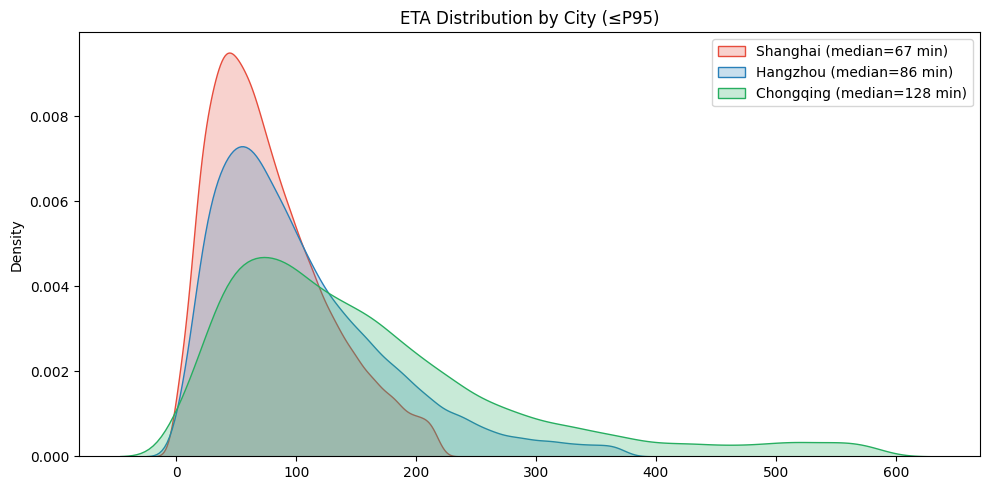

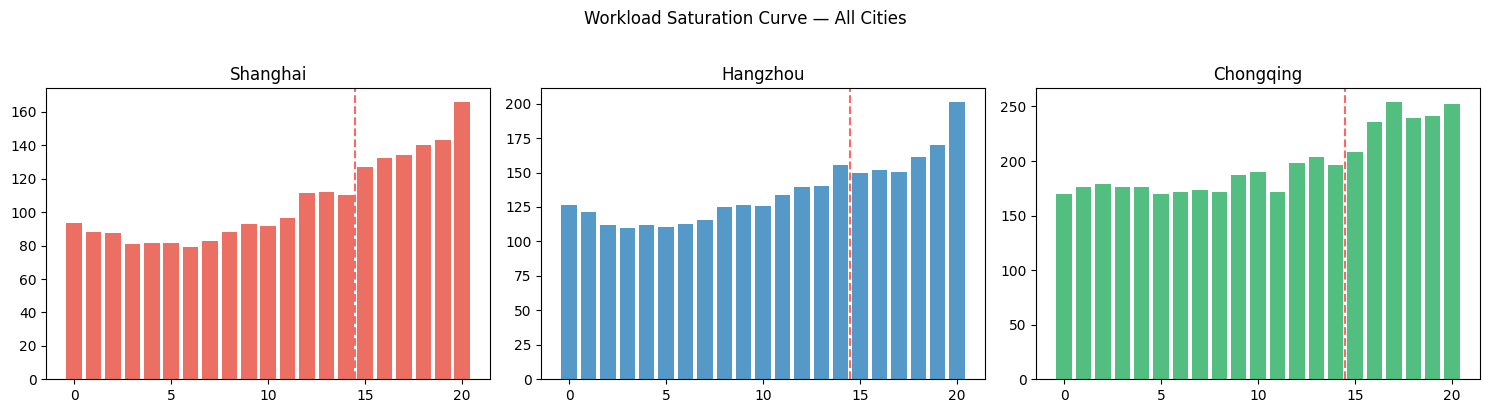

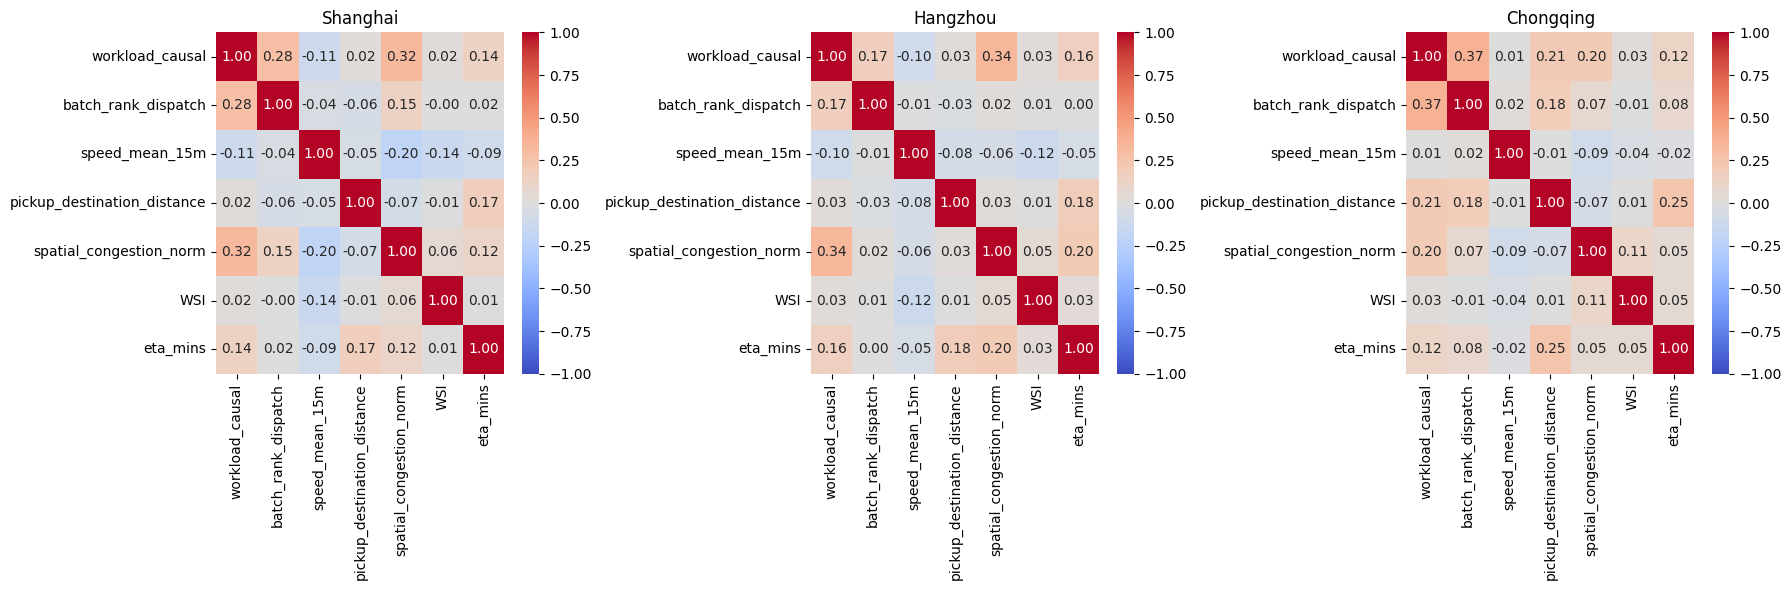

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import polars as pl
import numpy as np

def plot_eta_by_city(city_results, clip_pct=0.95):
    fig, ax = plt.subplots(figsize=(10, 5))
    colors = {"Shanghai": "#e74c3c", "Hangzhou": "#2980b9", "Chongqing": "#27ae60"}
    for city, df in city_results.items():
        cap = df["eta_mins"].quantile(clip_pct)
        data = df.filter(pl.col("eta_mins") <= cap)["eta_mins"].to_numpy()
        med = float(np.median(data))
        sns.kdeplot(data, ax=ax, label=f"{city} (median={med:.0f} min)", color=colors.get(city), fill=True, alpha=0.25)
    ax.set_title(f"ETA Distribution by City (\u2264P{int(clip_pct*100)})")
    ax.legend()
    plt.tight_layout()
    plt.show()

def plot_saturation_by_city(city_results):
    fig, axes = plt.subplots(1, len(city_results), figsize=(15, 4))
    colors = {"Shanghai": "#e74c3c", "Hangzhou": "#2980b9", "Chongqing": "#27ae60"}
    for ax, (city, df) in zip(axes, city_results.items()):
        plot_df = df.with_columns(pl.col("workload_causal").clip(upper_bound=20)).group_by("workload_causal").agg(pl.mean("eta_mins").alias("mean_eta")).sort("workload_causal").to_pandas()
        ax.bar(plot_df["workload_causal"], plot_df["mean_eta"], color=colors.get(city, "steelblue"), alpha=0.8)
        ax.axvline(x=14.5, color="red", linestyle="--", alpha=0.6)
        ax.set_title(city)
    plt.suptitle("Workload Saturation Curve \u2014 All Cities", y=1.02)
    plt.tight_layout()
    plt.show()

def plot_feature_corr_heatmap(city_results):
    key_features = ["workload_causal", "batch_rank_dispatch", "speed_mean_15m", "pickup_destination_distance", "spatial_congestion_norm", "WSI", "eta_mins"]
    fig, axes = plt.subplots(1, len(city_results), figsize=(18, 6))
    for ax, (city, df) in zip(axes, city_results.items()):
        avail = [c for c in key_features if c in df.columns]
        corr_mat = df.select(avail).to_pandas().corr()
        sns.heatmap(corr_mat, ax=ax, cmap="coolwarm", center=0, annot=True, fmt=".2f", vmin=-1, vmax=1)
        ax.set_title(city)
    plt.tight_layout()
    plt.show()

print("Generating updated visualizations for Stage 1 results...")
plot_eta_by_city(city_results_v4)
plot_saturation_by_city(city_results_v4)
plot_feature_corr_heatmap(city_results_v4)

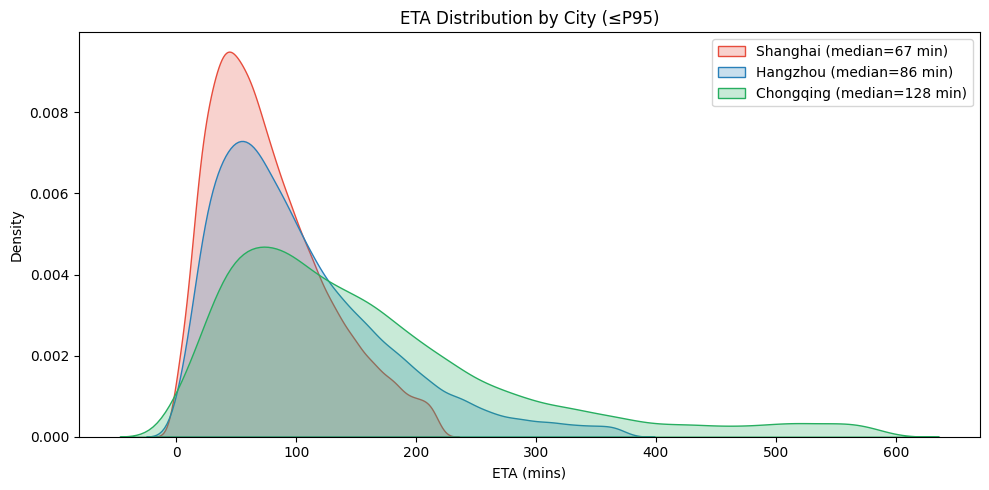

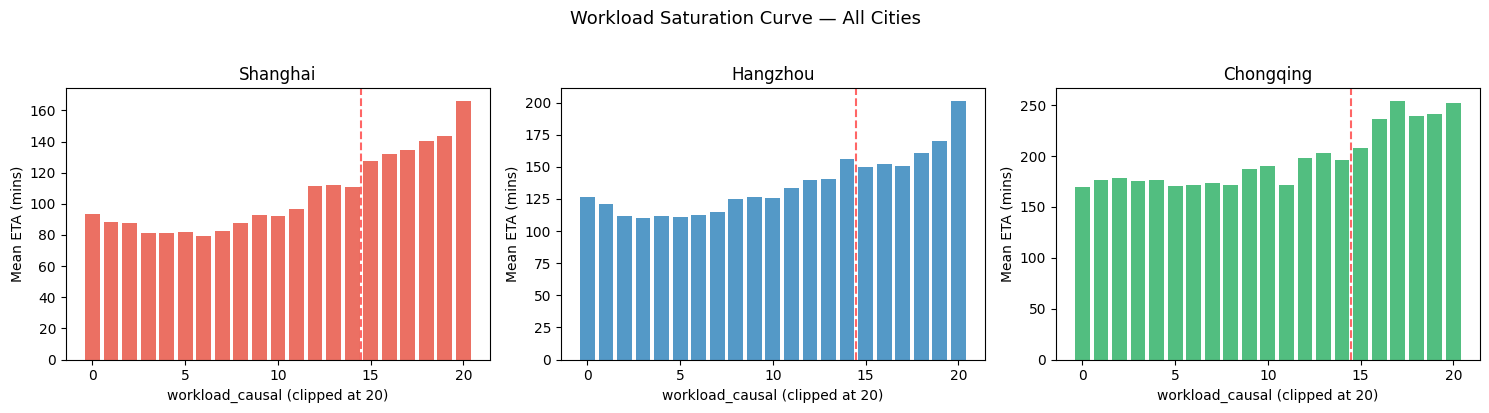

/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2922: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2923: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]
/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2922: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2923: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]
/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2922: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2923: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


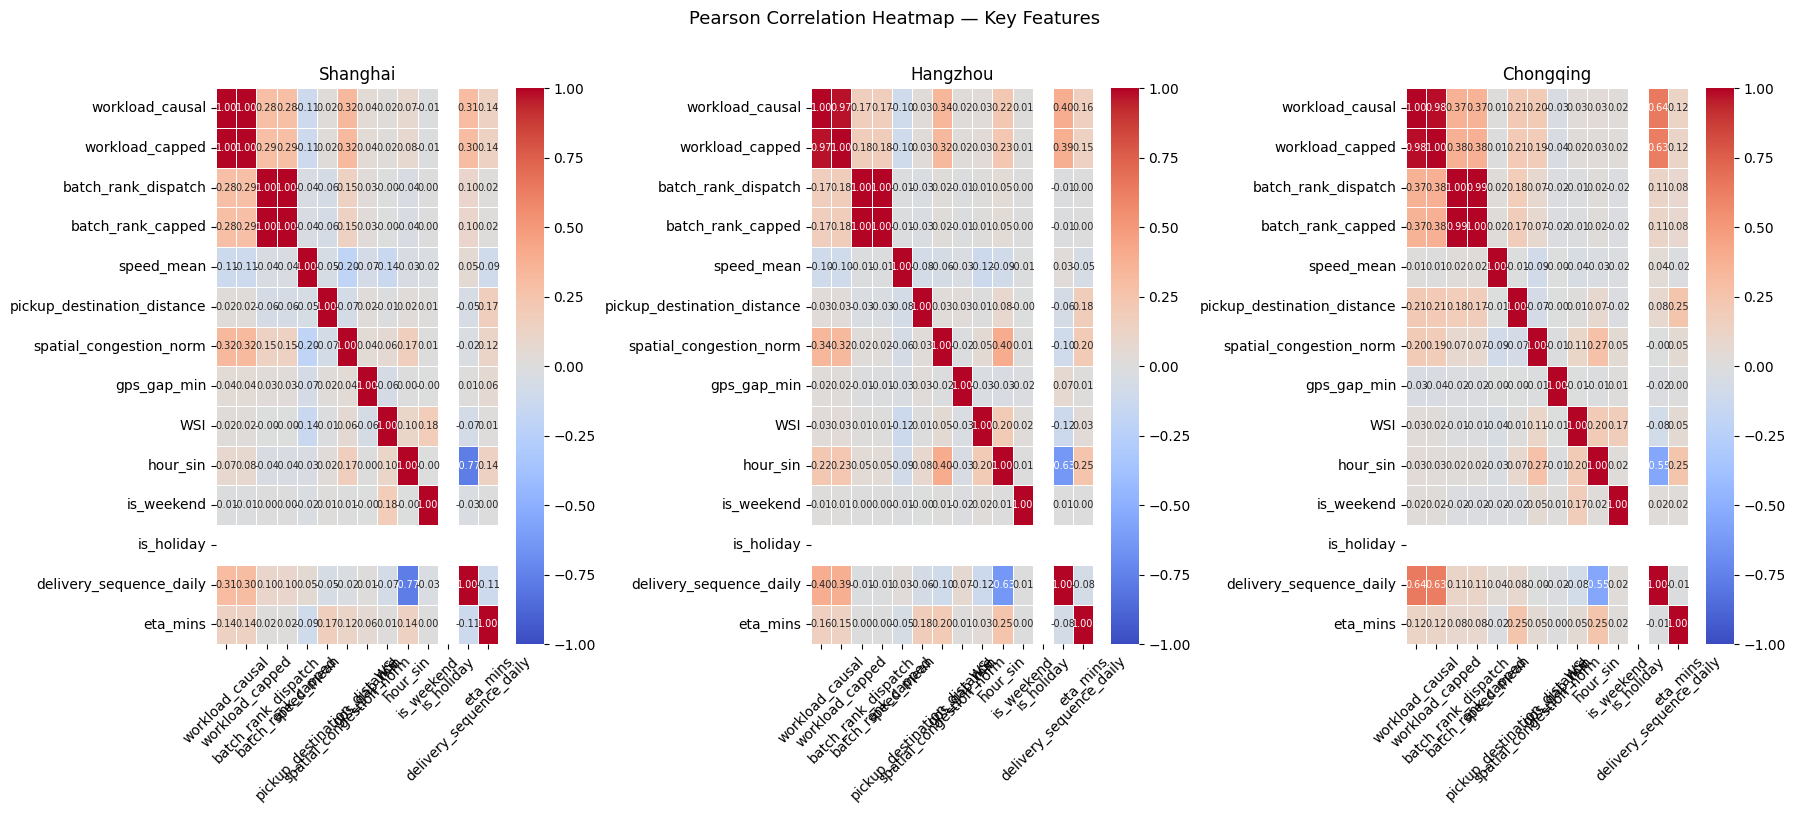

In [ ]:
def plot_eta_by_city(city_results: dict, clip_pct: float = 0.95) -> None:
    """ETA KDE overlay for all cities on one axis."""
    fig, ax = plt.subplots(figsize=(10, 5))
    colors = {"Shanghai": "#e74c3c", "Hangzhou": "#2980b9", "Chongqing": "#27ae60"}
    for city, df in city_results.items():
        cap  = df["eta_mins"].quantile(clip_pct)
        data = df.filter(pl.col("eta_mins") <= cap)["eta_mins"].to_numpy()
        med  = float(np.median(data))
        sns.kdeplot(data, ax=ax, label=f"{city} (median={med:.0f} min)",
                    color=colors.get(city), fill=True, alpha=0.25)
    ax.set_xlabel("ETA (mins)")
    ax.set_ylabel("Density")
    ax.set_title(f"ETA Distribution by City (≤P{int(clip_pct*100)})")
    ax.legend()
    plt.tight_layout()
    plt.show()


def plot_saturation_by_city(city_results: dict) -> None:
    """Workload saturation curves — 1×3 subplot grid. Uses workload_causal (v2)."""
    fig, axes = plt.subplots(1, len(city_results), figsize=(15, 4), sharey=False)
    colors = {"Shanghai": "#e74c3c", "Hangzhou": "#2980b9", "Chongqing": "#27ae60"}
    for ax, (city, df) in zip(axes, city_results.items()):
        plot_df = (
            df.with_columns(pl.col("workload_causal").clip(upper_bound=20))
            .group_by("workload_causal")
            .agg(pl.mean("eta_mins").alias("mean_eta"))
            .sort("workload_causal")
            .to_pandas()
        )
        ax.bar(plot_df["workload_causal"], plot_df["mean_eta"],
               color=colors.get(city, "steelblue"), alpha=0.8)
        ax.axvline(x=14.5, color="red", linestyle="--", alpha=0.6)
        ax.set_title(city)
        ax.set_xlabel("workload_causal (clipped at 20)")
        ax.set_ylabel("Mean ETA (mins)")
    plt.suptitle("Workload Saturation Curve — All Cities", fontsize=13, y=1.02)
    plt.tight_layout()
    plt.show()


def plot_feature_corr_heatmap(city_results: dict) -> None:
    """Side-by-side correlation heatmaps (key features vs eta_mins)."""
    key_features = [
        "workload_causal", "workload_capped",
        "batch_rank_dispatch", "batch_rank_capped",
        "speed_mean", "pickup_destination_distance",
        "spatial_congestion_norm", "gps_gap_min",
        "WSI", "hour_sin", "is_weekend", "is_holiday",
        "delivery_sequence_daily", "eta_mins",
    ]
    fig, axes = plt.subplots(1, len(city_results), figsize=(18, 8))
    for ax, (city, df) in zip(axes, city_results.items()):
        avail = [c for c in key_features if c in df.columns]
        corr_mat = df.select(avail).corr().to_pandas()
        corr_mat.columns = avail
        corr_mat.index   = avail
        sns.heatmap(corr_mat, ax=ax, cmap="coolwarm", center=0,
                    annot=True, fmt=".2f", annot_kws={"size": 7},
                    linewidths=0.4, vmin=-1, vmax=1)
        ax.set_title(city)
        ax.tick_params(axis="x", rotation=45)
        ax.tick_params(axis="y", rotation=0)
    plt.suptitle("Pearson Correlation Heatmap — Key Features", fontsize=13, y=1.01)
    plt.tight_layout()
    plt.show()


# ── Run cross-city plots ──────────────────────────────────────────────────────
plot_eta_by_city(city_results)
plot_saturation_by_city(city_results)
plot_feature_corr_heatmap(city_results)

### 5.1 Post-Processing & Additional Sanity Checks
Handling missing trajectory data by filling with 0 and verifying feature consistency.

## 8. Advanced EDA — Spatial, Interaction & SHAP

Five specialized diagnostics for the thesis documentation:
1. **Courier Ridgeline** — ETA distribution across top-N couriers (joypy)
2. **Temporal Heatmap** — Day × Hour mean ETA (Qingming Festival visible)
3. **Spatial Overlay** — grid-based delivery density vs mean ETA bottlenecks
4. **Workload–Batch Interaction** — 2D heatmap of workload × batch rank
5. **SHAP Feature Importance** — XGBoost + beeswarm plot per city

In [ ]:
!pip install shap joypy xgboost --quiet
import shap
import joypy
import xgboost
print(f"SHAP {shap.__version__} | XGBoost {xgboost.__version__}")

SHAP 0.51.0 | XGBoost 3.2.0


In [ ]:
# def plot_courier_ridgeline(features: pl.DataFrame, city_en: str, top_n: int = 20) -> None:
#     """
#     Ridgeline plot of ETA distribution for the top-N most active couriers.
#     Reveals between-courier performance variance — a key source of ETA uncertainty
#     that workload and batch features alone cannot explain.
#     """
#     top_couriers = (
#         features.group_by("delivery_user_id")
#         .len()
#         .sort("len", descending=True)
#         .head(top_n)
#         .get_column("delivery_user_id")
#         .to_list()
#     )
#     plot_df = features.filter(pl.col("delivery_user_id").is_in(top_couriers)).to_pandas()
#     fig, axes = joypy.joyplot(
#         plot_df, by="delivery_user_id", column="eta_mins",
#         range_style="own", grid="y", linewidth=1, legend=False,
#         title=f"Courier ETA Distribution (Top {top_n}) — {city_en}",
#         colormap=plt.cm.viridis, alpha=0.6, figsize=(10, 8)
#     )
#     plt.show()


# def plot_temporal_heatmap(features: pl.DataFrame, city_en: str) -> None:
#     """
#     Day-of-month × Hour heatmap of mean ETA.
#     Captures Qingming Festival spike (April 3–5) and daily delivery peaks (9am, 5pm).
#     """
#     heatmap_data = (
#         features.with_columns([
#             pl.col("receipt_time").dt.day().alias("day"),
#             pl.col("receipt_time").dt.hour().alias("hour"),
#         ])
#         .group_by(["day", "hour"])
#         .agg(pl.mean("eta_mins").alias("mean_eta"))
#         .to_pandas()
#     )
#     pivot_df = heatmap_data.pivot(index="hour", columns="day", values="mean_eta").sort_index()
#     plt.figure(figsize=(14, 7))
#     sns.heatmap(pivot_df, cmap="YlOrRd", annot=True, fmt=".0f",
#                 cbar_kws={"label": "Mean ETA (mins)"})
#     plt.title(f"Temporal ETA Heatmap: Day of Month vs Hour — {city_en}\n"
#               f"(April 3–5: Qingming Festival)")
#     plt.xlabel("Day of Month (April 2021)")
#     plt.ylabel("Hour of Day")
#     plt.tight_layout()
#     plt.show()


# def plot_spatial_overlay(features: pl.DataFrame, city_en: str) -> None:
#     """
#     Scatter plot: delivery density (left) and mean ETA (right) per grid cell.
#     Red zones on the right panel identify geographic bottlenecks where ETA
#     consistently degrades — targets for micro-fulfilment centre placement.
#     """
#     spatial_stats = (
#         features.group_by(["grid_x", "grid_y"])
#         .agg([pl.len().alias("density"), pl.mean("eta_mins").alias("mean_eta")])
#         .to_pandas()
#     )
#     fig, ax = plt.subplots(1, 2, figsize=(18, 7))
#     sc1 = ax[0].scatter(spatial_stats["grid_x"], spatial_stats["grid_y"],
#                         c=spatial_stats["density"], cmap="viridis", s=20, alpha=0.7)
#     plt.colorbar(sc1, ax=ax[0], label="Number of Deliveries")
#     ax[0].set_title(f"Delivery Density — {city_en}")
#     ax[0].set_xlabel("Grid X (Affine)"); ax[0].set_ylabel("Grid Y (Affine)")

#     sc2 = ax[1].scatter(spatial_stats["grid_x"], spatial_stats["grid_y"],
#                         c=spatial_stats["mean_eta"], cmap="Reds", s=20, alpha=0.7)
#     plt.colorbar(sc2, ax=ax[1], label="Mean ETA (mins)")
#     ax[1].set_title(f"Spatial ETA Bottlenecks — {city_en}")
#     ax[1].set_xlabel("Grid X (Affine)"); ax[1].set_ylabel("Grid Y (Affine)")
#     plt.tight_layout(); plt.show()


# def plot_workload_batch_interaction(features: pl.DataFrame, city_en: str) -> None:
#     """
#     2D heatmap: workload_capped × batch_rank_capped → mean ETA.
#     Dark-red (high ETA) cells reveal the M/G/1 'danger zone' where
#     both queue depth and sequence position exceed operational capacity.
#     Uses dispatch rank to avoid leakage.
#     """
#     interaction_df = (
#         features.group_by(["workload_capped", "batch_rank_capped"])
#         .agg(pl.mean("eta_mins").alias("mean_eta"))
#         .to_pandas()
#     )
#     pivot_df = interaction_df.pivot(
#         index="workload_capped", columns="batch_rank_capped", values="mean_eta"
#     ).sort_index()
#     plt.figure(figsize=(12, 8))
#     sns.heatmap(pivot_df, annot=True, fmt=".1f", cmap="rocket_r",
#                 cbar_kws={"label": "Mean ETA (mins)"})
#     plt.title(f"Interaction: workload_capped × batch_rank_capped — {city_en}")
#     plt.xlabel("batch_rank_capped (dispatch)"); plt.ylabel("workload_capped")
#     plt.tight_layout(); plt.show()


# def plot_shap_relevance(features: pl.DataFrame, city_en: str) -> None:
#     """
#     Train XGBoost on engineered features and show SHAP beeswarm plot.
#     Uses v2 column names (workload_causal → workload_capped, batch_rank_dispatch → batch_rank_capped).
#     """
#     model_features = [
#         "batch_size", "batch_rank_capped", "workload_capped",
#         "delivery_sequence_daily",
#         "speed_mean", "distance_travelled", "gps_points", "gps_gap_min",
#         "is_trajectory_available", "pickup_destination_distance",
#         "hour_sin", "hour_cos", "day_sin", "day_cos",
#         "is_holiday", "is_holiday_eve", "is_weekend",
#         "WSI", "precipitation", "temperature_2m", "windspeed_10m",
#         "typecode_grouped_type 1", "typecode_grouped_type 2",
#         "typecode_grouped_type 3", "typecode_cb",
#         "spatial_congestion_norm", "courier_local_load",
#     ]
#     avail_cols = [c for c in model_features if c in features.columns]
#     X = features.select(avail_cols).to_pandas().fillna(0)
#     y = features["eta_mins"].to_numpy()

#     model = xgboost.XGBRegressor(
#         n_estimators=100, max_depth=6, learning_rate=0.1, random_state=42
#     )
#     model.fit(X, y)

#     explainer   = shap.Explainer(model, X)
#     shap_values = explainer(X)

#     plt.figure(figsize=(10, 8))
#     plt.title(f"SHAP Feature Importance — {city_en}")
#     shap.plots.beeswarm(shap_values, show=False)
#     plt.tight_layout(); plt.show()


# def run_advanced_eda(city_results: dict) -> None:
#     """
#     Executes all five advanced visualizations for every city and prints
#     a cross-city thesis insight summary.
#     """
#     for city_name, df in city_results.items():
#         print(f"\n{'='*60}")
#         print(f"  Advanced EDA: {city_name}")
#         print(f"{'='*60}")
#         plot_courier_ridgeline(df, city_name)
#         plot_temporal_heatmap(df, city_name)
#         plot_spatial_overlay(df, city_name)
#         plot_workload_batch_interaction(df, city_name)
#         plot_shap_relevance(df, city_name)

#     print("\n--- Cross-City Thesis Insights ---")
#     print("1. Temporal:     ETA spikes visible across all cities during Qingming (Apr 3–5).")
#     print("2. Couriers:     Ridgelines show high between-courier variance; workload alone")
#     print("                 cannot explain it — individual routing efficiency matters.")
#     print("3. Saturation:   Interaction heatmaps confirm M/G/1 non-linearity when")
#     print("                 workload_causal > 15 AND batch_rank_dispatch > 8.")
#     print("4. SHAP:         workload_capped, pickup_destination_distance, and WSI")
#     print("                 consistently rank as top ETA predictors across all cities.")
#     print("5. Chongqing:    Spatial overlays show concentrated high-ETA zones consistent")
#     print("                 with its topographic constraints (hilly terrain, river splits).")


# run_advanced_eda(city_results)

NameError: name 'city_results' is not defined


Processing Shanghai...


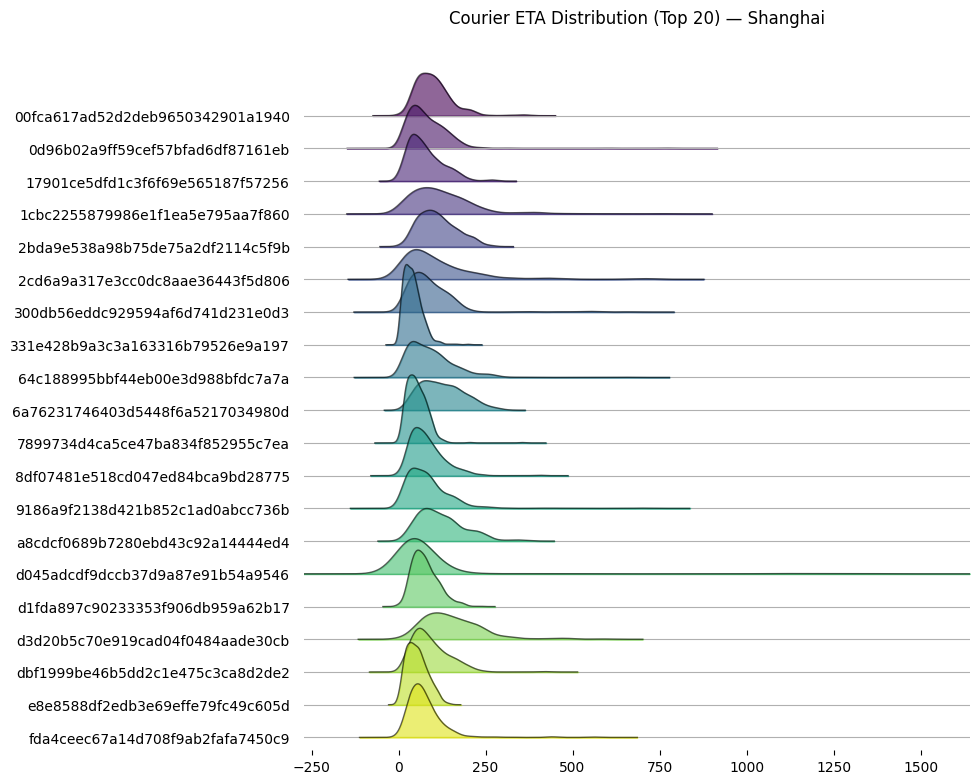

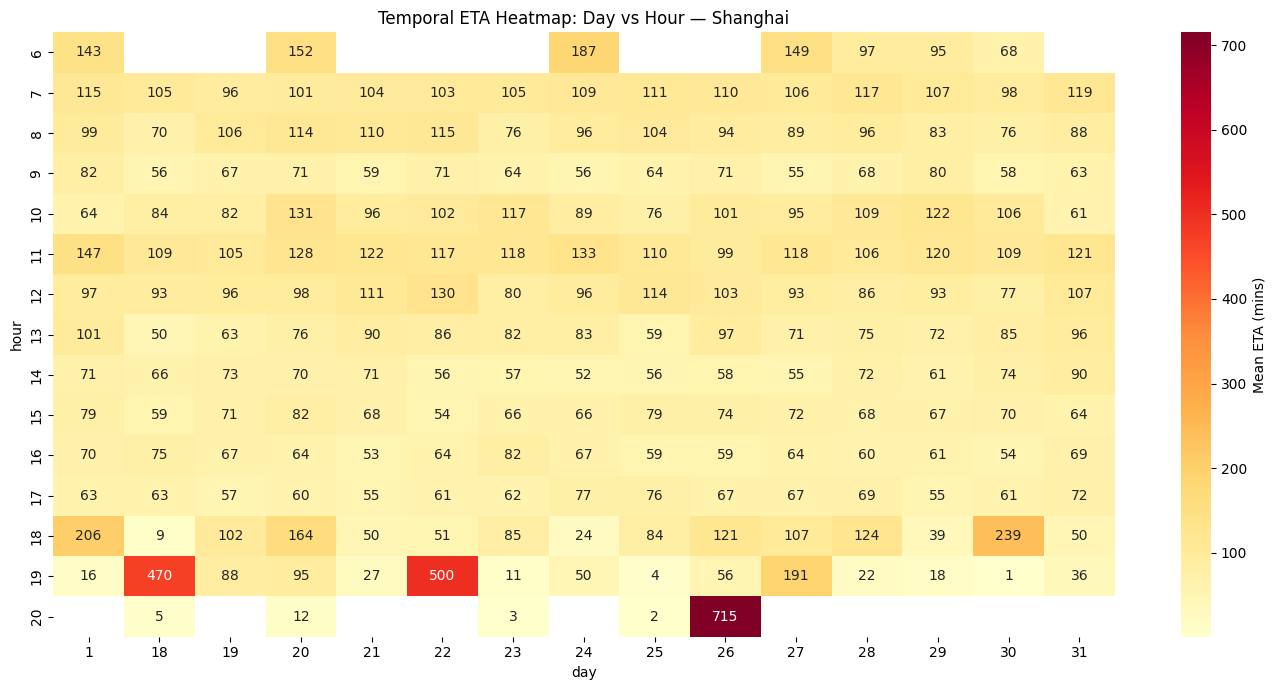

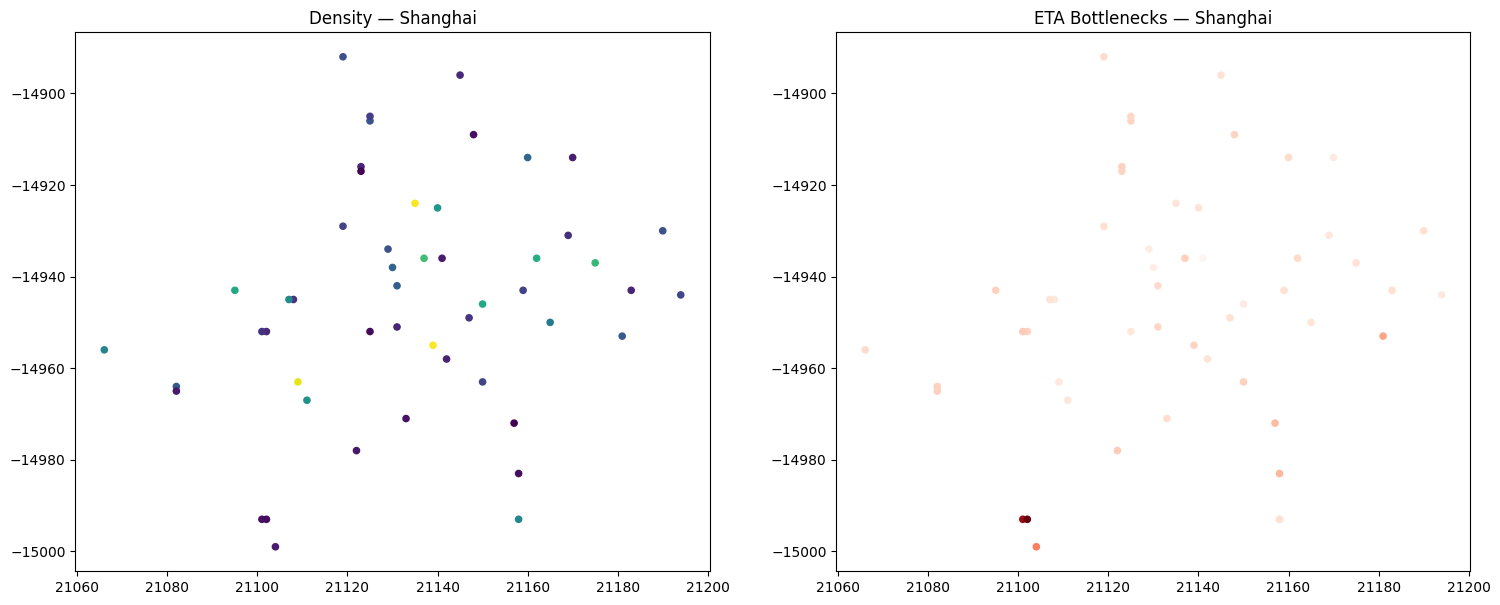

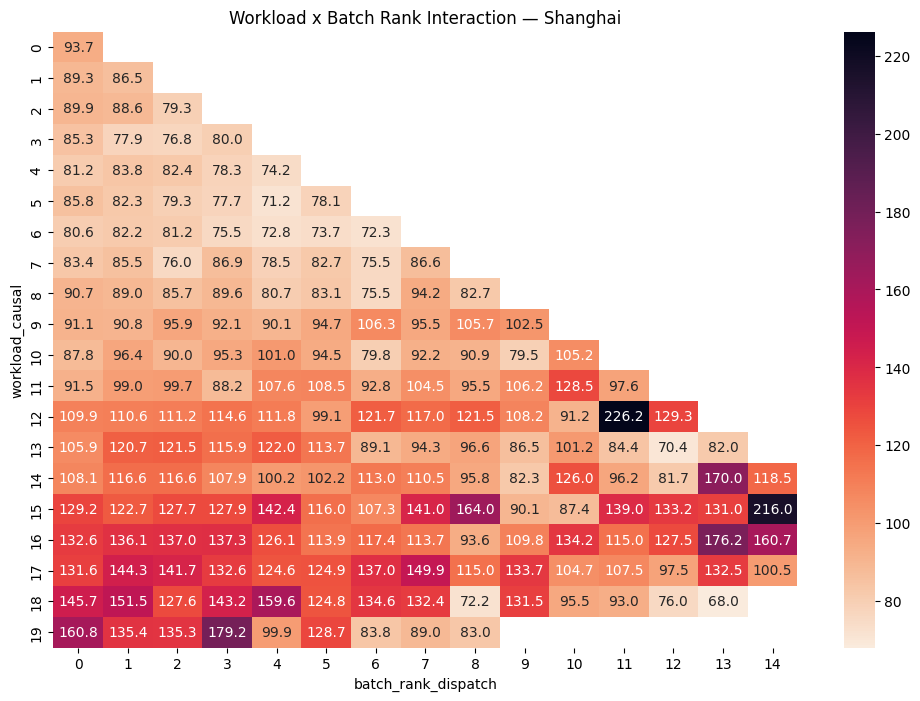

 99%|===================| 34084/34480 [00:47<00:00]       

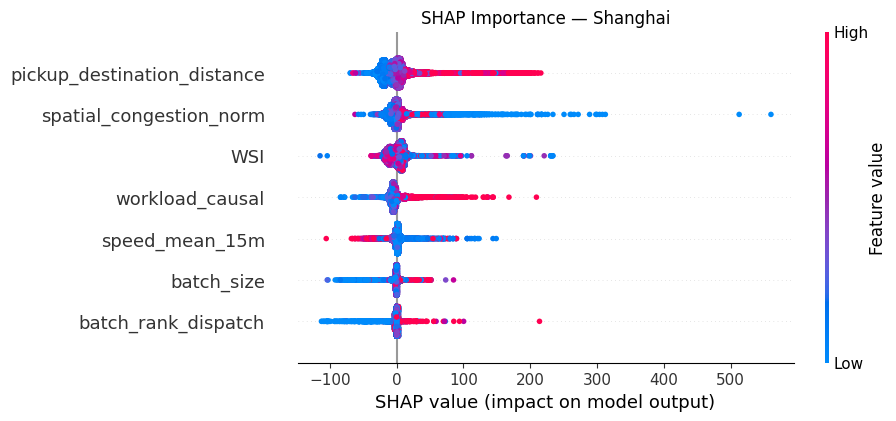


Processing Hangzhou...


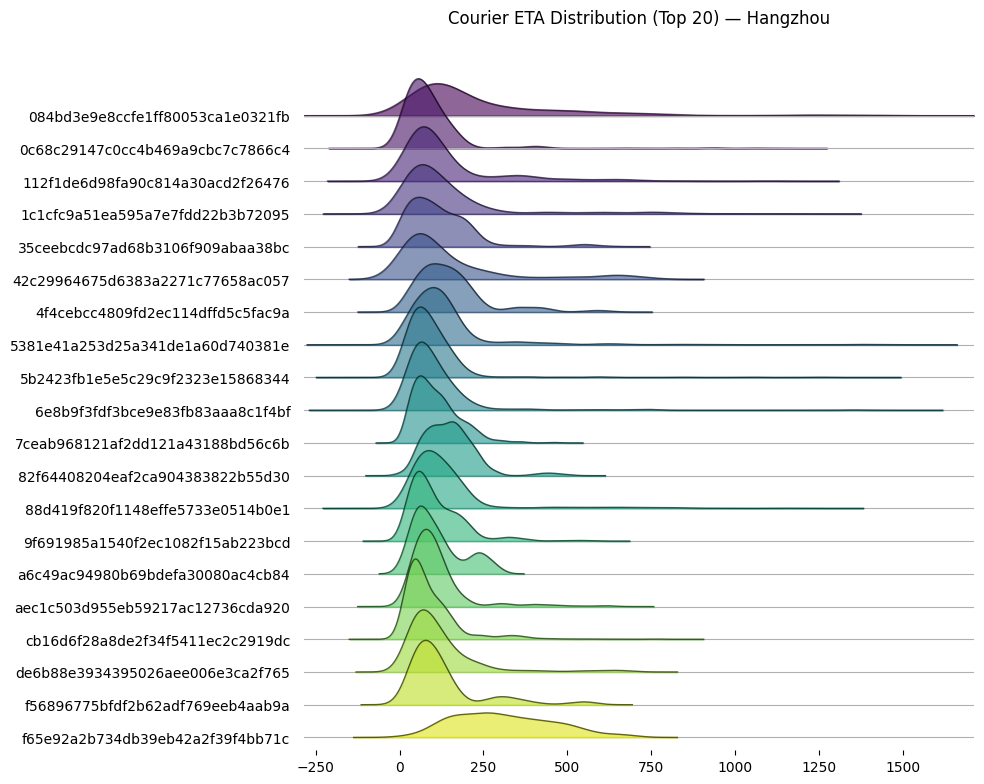

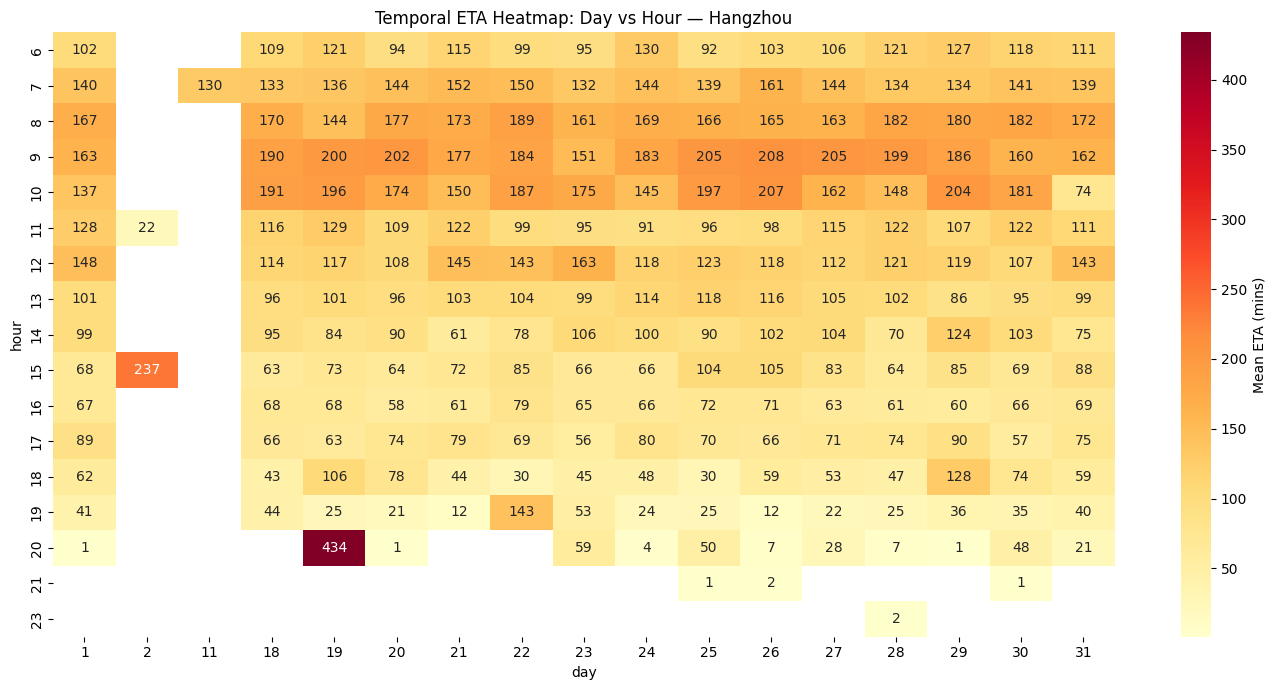

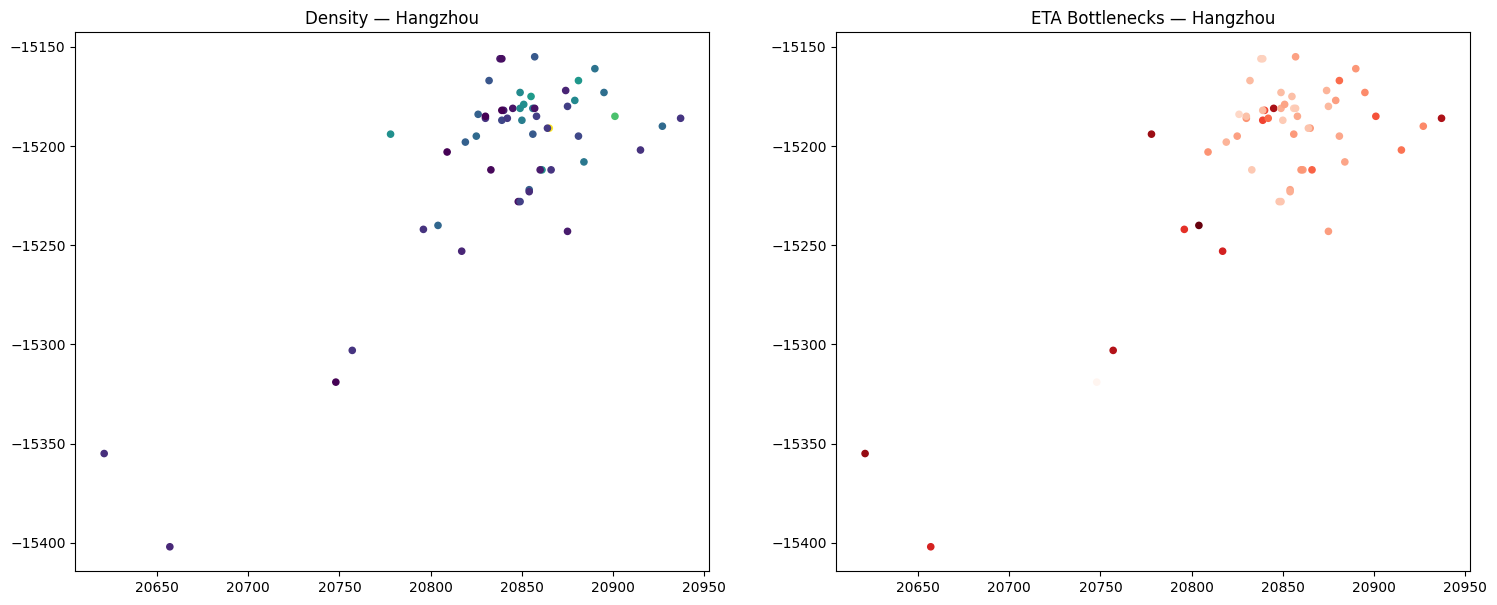

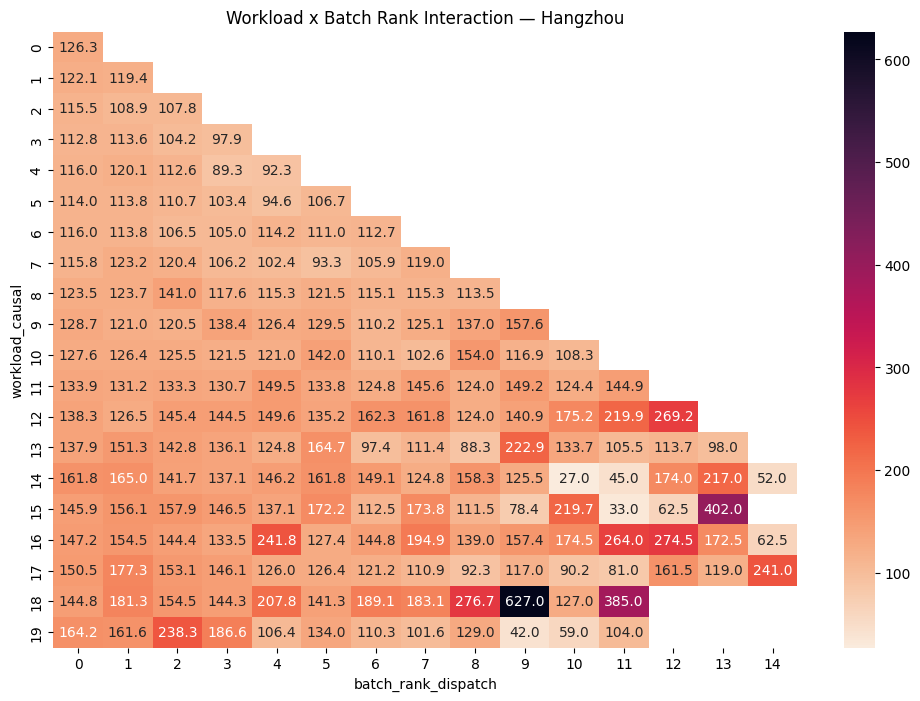

 98%|===================| 39648/40348 [01:01<00:01]       

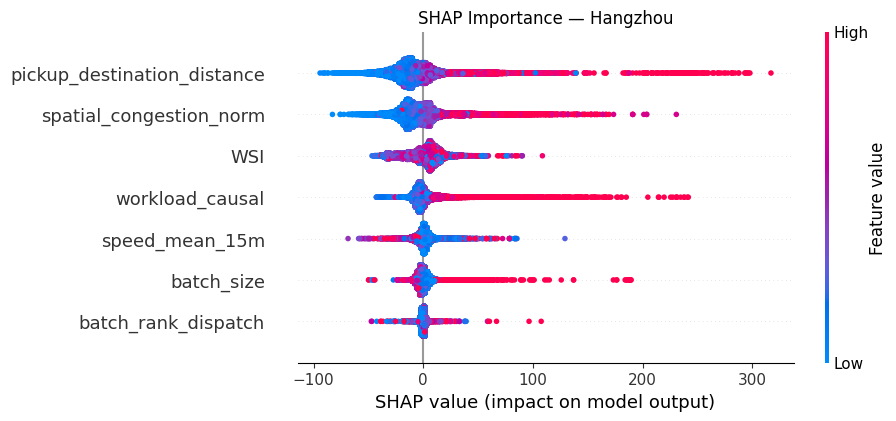


Processing Chongqing...


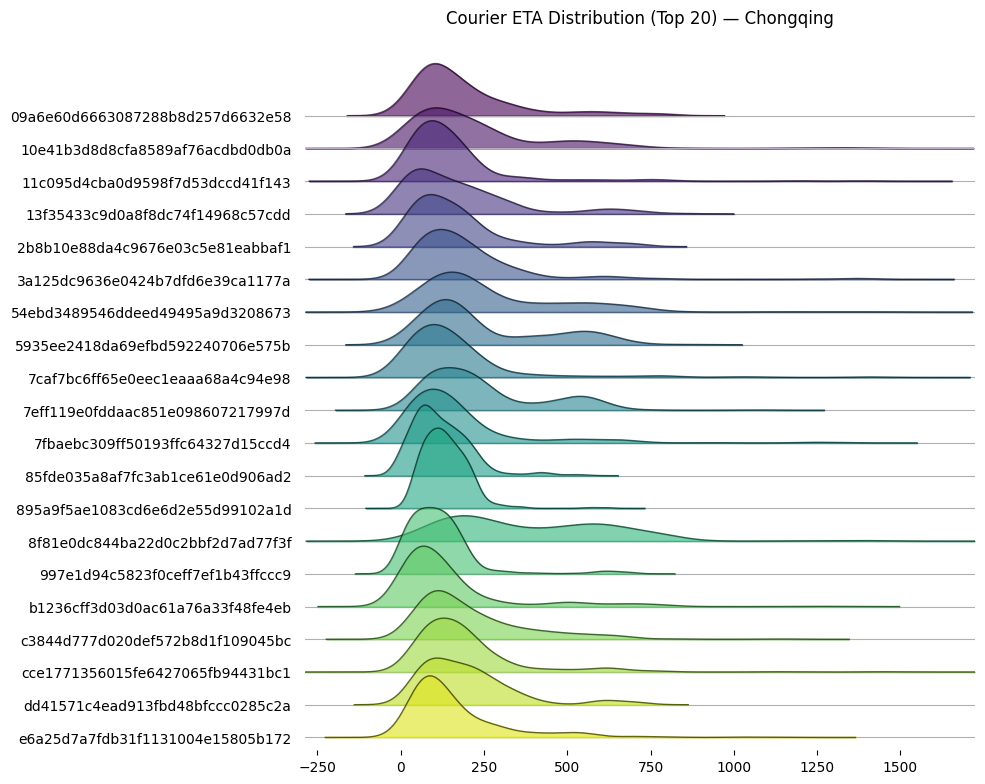

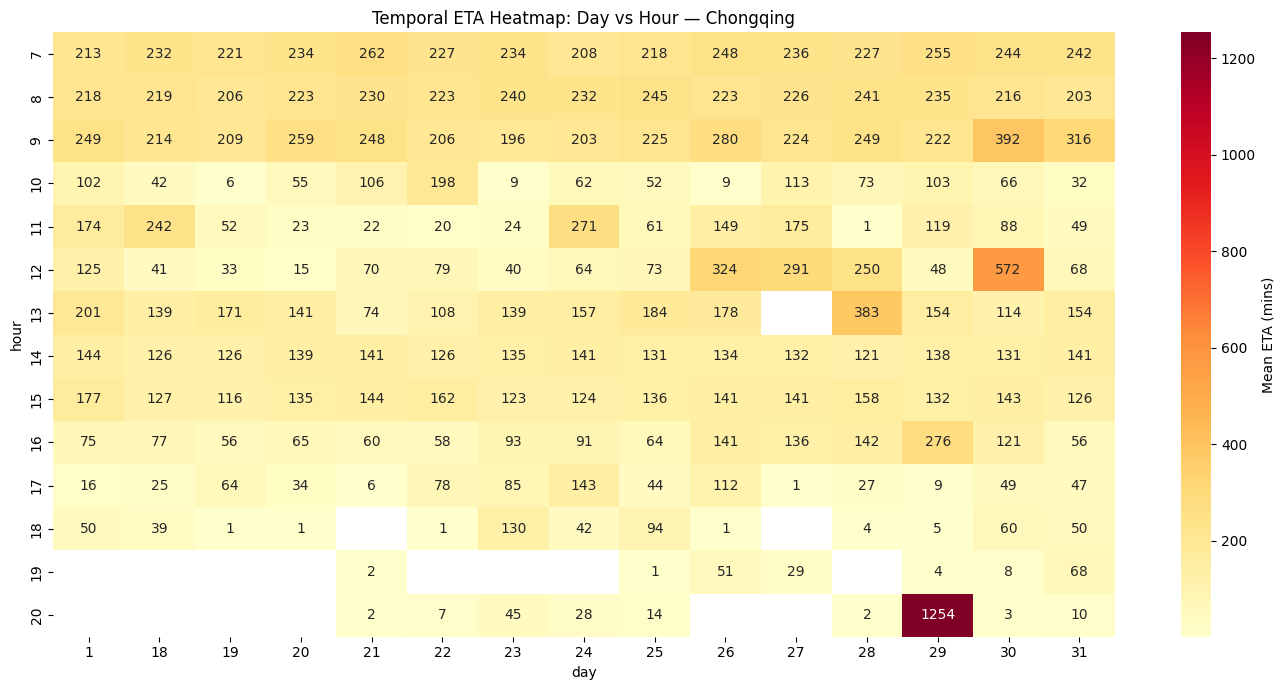

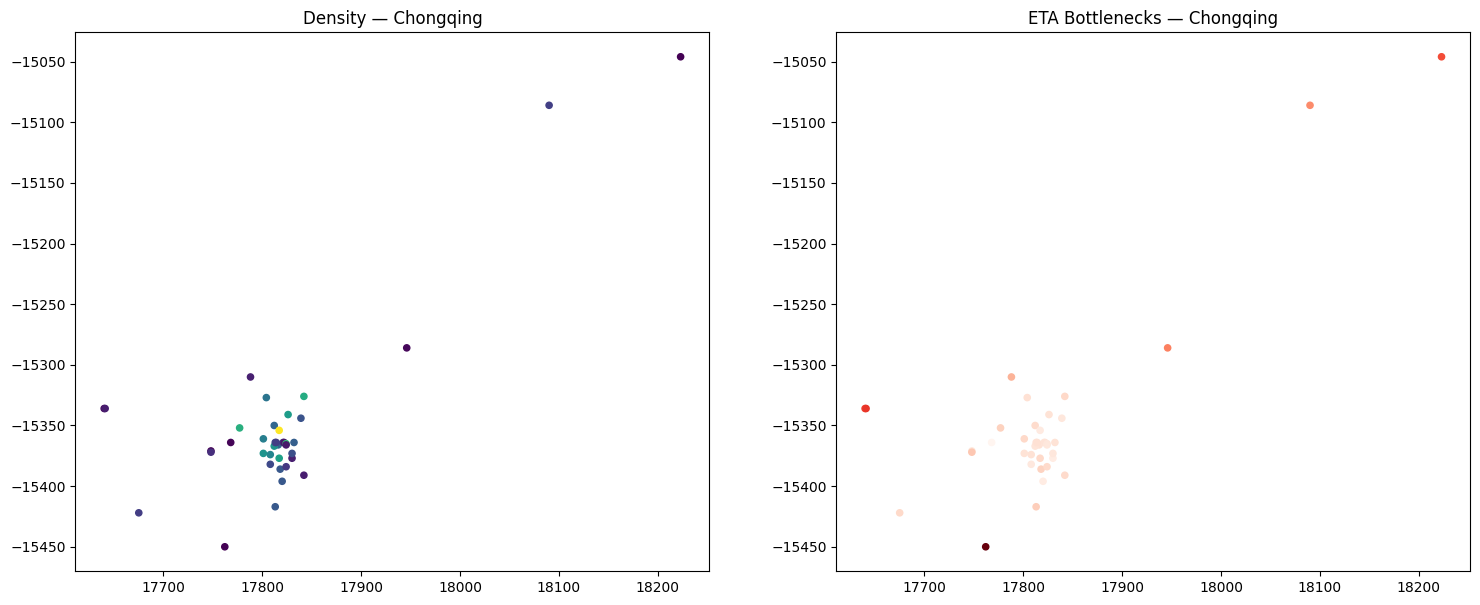

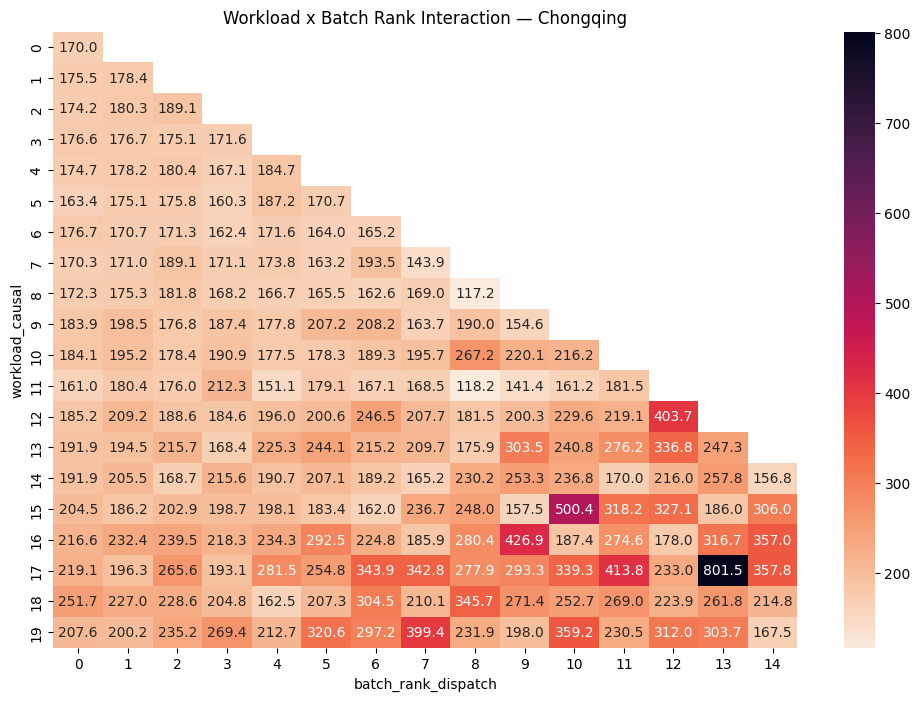

 98%|===================| 24719/25335 [00:36<00:00]       

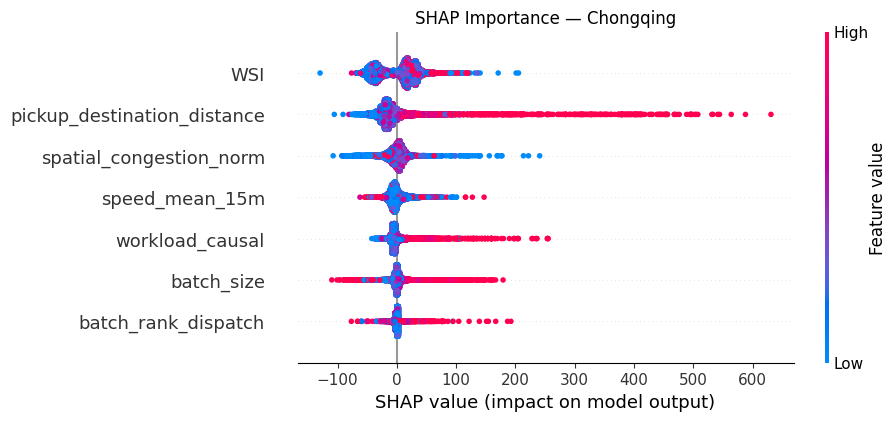

In [ ]:
import shap
import joypy
import xgboost
import matplotlib.pyplot as plt
import seaborn as sns
import polars as pl
import numpy as np

def plot_courier_ridgeline(features, city_en, top_n=20):
    top_couriers = features.group_by("delivery_user_id").len().sort("len", descending=True).head(top_n).get_column("delivery_user_id").to_list()
    plot_df = features.filter(pl.col("delivery_user_id").is_in(top_couriers)).to_pandas()
    joypy.joyplot(plot_df, by="delivery_user_id", column="eta_mins", range_style="own", grid="y", linewidth=1, title=f"Courier ETA Distribution (Top {top_n}) — {city_en}", colormap=plt.cm.viridis, alpha=0.6, figsize=(10, 8))
    plt.show()

def plot_temporal_heatmap(features, city_en):
    heatmap_data = features.with_columns([pl.col("receipt_time").dt.day().alias("day"), pl.col("receipt_time").dt.hour().alias("hour")]).group_by(["day", "hour"]).agg(pl.mean("eta_mins").alias("mean_eta")).to_pandas()
    pivot_df = heatmap_data.pivot(index="hour", columns="day", values="mean_eta").sort_index()
    plt.figure(figsize=(14, 7))
    sns.heatmap(pivot_df, cmap="YlOrRd", annot=True, fmt=".0f", cbar_kws={"label": "Mean ETA (mins)"})
    plt.title(f"Temporal ETA Heatmap: Day vs Hour — {city_en}")
    plt.tight_layout()
    plt.show()

def plot_spatial_overlay(features, city_en):
    spatial_stats = features.group_by(["grid_x", "grid_y"]).agg([pl.len().alias("density"), pl.mean("eta_mins").alias("mean_eta")]).to_pandas()
    fig, ax = plt.subplots(1, 2, figsize=(18, 7))
    ax[0].scatter(spatial_stats["grid_x"], spatial_stats["grid_y"], c=spatial_stats["density"], cmap="viridis", s=20)
    ax[0].set_title(f"Density — {city_en}")
    ax[1].scatter(spatial_stats["grid_x"], spatial_stats["grid_y"], c=spatial_stats["mean_eta"], cmap="Reds", s=20)
    ax[1].set_title(f"ETA Bottlenecks — {city_en}")
    plt.show()

def plot_workload_batch_interaction(features, city_en):
    interaction_df = features.group_by(["workload_causal", "batch_rank_dispatch"]).agg(pl.mean("eta_mins").alias("mean_eta")).to_pandas()
    pivot_df = interaction_df.pivot(index="workload_causal", columns="batch_rank_dispatch", values="mean_eta").sort_index()
    plt.figure(figsize=(12, 8))
    sns.heatmap(pivot_df.iloc[:20, :15], annot=True, fmt=".1f", cmap="rocket_r")
    plt.title(f"Workload x Batch Rank Interaction — {city_en}")
    plt.show()

def plot_shap_relevance(features, city_en):
    model_features = ["batch_size", "batch_rank_dispatch", "workload_causal", "speed_mean_15m", "pickup_destination_distance", "WSI", "spatial_congestion_norm"]
    avail_cols = [c for c in model_features if c in features.columns]
    X = features.select(avail_cols).to_pandas().fillna(0)
    y = features["eta_mins"].to_numpy()
    model = xgboost.XGBRegressor(n_estimators=50, max_depth=5, random_state=42).fit(X, y)
    explainer = shap.Explainer(model, X)
    shap_values = explainer(X)
    plt.figure(figsize=(10, 6))
    shap.plots.beeswarm(shap_values, show=False)
    plt.title(f"SHAP Importance — {city_en}")
    plt.show()

def run_advanced_eda(city_results):
    for city_name, df in city_results.items():
        print(f"\nProcessing {city_name}...")
        plot_courier_ridgeline(df, city_name)
        plot_temporal_heatmap(df, city_name)
        plot_spatial_overlay(df, city_name)
        plot_workload_batch_interaction(df, city_name)
        plot_shap_relevance(df, city_name)

run_advanced_eda(city_results_v4)

## 9. Feature Summary Table

Compact per-city summary for thesis documentation.

In [ ]:
def feature_summary(city_results_dict: dict) -> None:
    """
    Print null counts and ETA statistics for all numeric features per city.
    Useful for the thesis dataset chapter and appendix.
    """
    for city, df in city_results_dict.items():
        print(f"\n{'─'*60}")
        print(f"  {city}  |  {df.height:,} rows × {len(df.columns)} cols")
        print(f"{'─'*60}")

        # Identify numeric columns using Polars types
        num_cols = [
            c for c, t in df.schema.items()
            if t.is_numeric()
        ]

        # Pre-calculate null counts for performance
        null_counts = df.select([pl.col(c).null_count().alias(c) for c in num_cols])

        print(f"  eta_mins  mean={df['eta_mins'].mean():.1f}  "
              f"median={df['eta_mins'].median():.1f}  "
              f"p95={df['eta_mins'].quantile(0.95):.1f}")

        print(f"\n  {'Feature':<40} {'Nulls':<10}")
        print(f"  {'-'*50}")
        for col in sorted(num_cols):
            n_null = null_counts[col].item()
            tag = f"⚠ {n_null}" if n_null > 0 else "0"
            print(f"  {col:<40} {tag:<10}")

# Run the summary using the latest city results
feature_summary(city_results_v4)


────────────────────────────────────────────────────────────
  Shanghai  |  34,480 rows × 55 cols
────────────────────────────────────────────────────────────
  eta_mins  mean=91.9  median=70.0  p95=218.0

  Feature                                  Nulls     
  --------------------------------------------------
  WSI                                      0         
  active_orders                            0         
  batch_rank_actual                        0         
  batch_rank_dispatch                      0         
  batch_size                               0         
  courier_eta_ewm                          0         
  distance_travelled_15m                   0         
  ds                                       0         
  eta_mins                                 0         
  gps_points                               0         
  grid_x                                   0         
  grid_y                                   0         
  hour                                

In [ ]:
# Verify the feature logic for a sample batch
verification_cols = [
    "batch_id",
    "batch_size",
    "batch_rank_actual",
    "pickup_destination_distance",
    "workload_causal",
    "eta_mins"
]

# Filter for a multi-order batch to see the sequence logic using the latest combined data
try:
    sample_batch_id = combined_v4.filter(pl.col("batch_size") > 2).get_column("batch_id")[0]

    verification_df = (
        combined_v4.filter(pl.col("batch_id") == sample_batch_id)
        .select([c for c in verification_cols if c in combined_v4.columns])
        .sort("batch_rank_actual")
    )

    print(f"Verification for Batch ID: {sample_batch_id}")
    display(verification_df)

    # Summary stats for key features across the whole dataset
    print("\nGlobal Summary of Key Features:")
    display(combined_v4.select(["workload_causal", "batch_size", "pickup_destination_distance"]).describe())
except Exception as e:
    print(f"Verification failed: {e}. Ensure combined_v4 is defined and contains batch data.")

Verification for Batch ID: 3db58cbea96232aa2a3a768858e210fa__1616050860


batch_id,batch_size,batch_rank_actual,pickup_destination_distance,workload_causal,eta_mins
str,u32,u32,f64,i32,f64
"""3db58cbea96232aa2a3a768858e210…",11,0,630.497507,12,26.0
"""3db58cbea96232aa2a3a768858e210…",11,1,624.611352,12,35.0
"""3db58cbea96232aa2a3a768858e210…",11,2,621.646722,12,41.0
"""3db58cbea96232aa2a3a768858e210…",11,3,1033.152954,12,61.0
"""3db58cbea96232aa2a3a768858e210…",11,4,1206.618283,12,68.0
…,…,…,…,…,…
"""3db58cbea96232aa2a3a768858e210…",11,6,936.455778,12,97.0
"""3db58cbea96232aa2a3a768858e210…",11,7,924.179876,12,106.0
"""3db58cbea96232aa2a3a768858e210…",11,8,894.146774,12,111.0



Global Summary of Key Features:


statistic,workload_causal,batch_size,pickup_destination_distance
str,f64,f64,f64
"""count""",100163.0,100163.0,100163.0
"""null_count""",0.0,0.0,0.0
"""mean""",7.672055,4.056178,2482.354116
"""std""",5.538844,2.992754,2911.167307
"""min""",0.0,1.0,4.06264
"""25%""",4.0,2.0,1141.927174
"""50%""",7.0,3.0,1917.906262
"""75%""",10.0,5.0,3008.179331
"""max""",52.0,26.0,72433.231735


---
***
---


---

BATCH AGGREGATION

---




 Step 2B — Aggregated Delivery Features
    (correct aggregation per feature type)

        Feature                  Aggregation     Reason
        ───────────────────────  ──────────────  ─────────────────────────────────
        workload_causal          first()         Constant within batch (same receipt_time)
        courier_local_load       first()         Constant within batch (same courier+hour)
        WSI                      first()         Constant within batch (same time+city)
        hour_sin, hour_cos       first()         Constant within batch
        is_weekend, is_holiday   first()         Constant within batch
        speed_mean_15m           mean()          Varies by order; true operational mean
        speed_std_15m            mean()          Varies by order
        idle_fraction            mean()          Varies by order
        coverage_ratio           mean()          Varies by order
        spatial_congestion_daily mean() + std()  Varies by POI grid cell → mean + cv
        rolling_congestion_3h    first()         Hour-level; constant within batch
        pickup_destination_dist  mean()          Varies by order
        remaining_haul_distance  mean()          Varies by order
        delivery_sequence_daily  mean()          Varies by batch_rank within batch
        courier_eta_ewm          first()         Courier-level; constant within batch
        typecode_cb              mean()          Varies by order


### 2.17 `aggregate_to_batch_level` — Stage 2A Entry Point

This function aggregates the order-level features into a batch-level dataset.

**Key Metrics:**
- **Spatial Diversity:** `batch_grid_cells_unique` counts distinct grid cells.
- **Operational state:** `workload_causal` and `WSI` (constant per batch).
- **Performance metrics:** Aggregated speed, distance, and ETA (mean/max/std).

In [ ]:
def aggregate_to_batch_level(df: pl.DataFrame) -> pl.DataFrame:
    """
    Aggregates order-level features to batch-level (unique batch_id).
    Follows the specific aggregation rules for Stage 2A.
    """
    # 1. Define aggregation expressions
    batch_aggs = [
        # Identification & Context (Constant per batch)
        pl.col("delivery_user_id").first(),
        pl.col("receipt_time").first(),
        pl.col("city").first().alias("city") if "city" in df.columns else pl.lit(None).alias("city"),

        # Features constant within batch
        pl.col("workload_causal").first(),
        pl.col("courier_eta_ewm").first(),
        pl.col("WSI").first(),
        pl.col("hour_sin").first(),
        pl.col("hour_cos").first(),
        pl.col("is_weekend").first(),
        pl.col("is_holiday").first(),
        pl.col("is_holiday_eve").first(),

        # Size and Diversity
        pl.len().alias("batch_size"),
        pl.col("grid_x").n_unique().alias("batch_grid_cells_unique"),

        # Operational Means (Varies by order)
        pl.col("speed_mean_15m").mean().alias("speed_mean_15m_mean"),
        pl.col("speed_std_15m").mean().alias("speed_std_15m_mean"),
        pl.col("distance_travelled_15m").mean().alias("distance_travelled_15m_mean"),
        pl.col("pickup_destination_distance").mean().alias("pickup_destination_distance_mean"),
        pl.col("remaining_haul_distance").mean().alias("remaining_haul_distance_mean"),
        pl.col("typecode_cb").mean().alias("typecode_cb_mean"),

        # Spatial Congestion Aggregates
        pl.col("spatial_congestion_daily").mean().alias("spatial_congestion_daily_mean"),
        pl.col("spatial_congestion_daily").std().alias("spatial_congestion_daily_std"),
        pl.col("spatial_congestion_norm").mean().alias("spatial_congestion_norm_mean"),
        pl.col("spatial_congestion_norm").std().alias("spatial_congestion_norm_std"),

        # Targets
        pl.col("eta_mins").mean().alias("eta_mean"),
        pl.col("eta_mins").max().alias("eta_max"),
        pl.col("eta_mins").std().alias("eta_std")
    ]

    batch_df = (
        df.group_by("batch_id")
        .agg(batch_aggs)
        .with_columns([
            # Add a flag for singleton batches to handle edge cases
            (pl.col("batch_size") == 1).cast(pl.Int8).alias("is_singleton_batch"),
            # Fill std dev nulls (from single-order batches) with 0
            pl.col("eta_std").fill_null(0),
            pl.col("spatial_congestion_daily_std").fill_null(0),
            pl.col("spatial_congestion_norm_std").fill_null(0)
        ])
        .sort(["delivery_user_id", "receipt_time"])
    )

    return batch_df

# Run aggregation for the combined dataset
batch_df_v4 = aggregate_to_batch_level(combined_v4)

# Save the aggregated batch data
batch_output_path = os.path.join(OUTPUT_DIR, "batch_aggregated_v4.parquet")
batch_df_v4.write_parquet(batch_output_path)

print(f"✅ Batch Aggregation Complete.")
print(f"Aggregated Shape: {batch_df_v4.shape[0]:,} batches x {batch_df_v4.shape[1]} columns")
display(batch_df_v4.head())


✅ Batch Aggregation Complete.
Aggregated Shape: 40,156 batches x 28 columns


batch_id,delivery_user_id,receipt_time,city,workload_causal,courier_eta_ewm,WSI,hour_sin,hour_cos,is_weekend,is_holiday,is_holiday_eve,batch_size,batch_grid_cells_unique,speed_mean_15m_mean,speed_std_15m_mean,distance_travelled_15m_mean,pickup_destination_distance_mean,remaining_haul_distance_mean,typecode_cb_mean,spatial_congestion_daily_mean,spatial_congestion_daily_std,spatial_congestion_norm_mean,spatial_congestion_norm_std,eta_mean,eta_max,eta_std,is_singleton_batch
str,str,datetime[μs],null,i32,f64,f64,f64,f64,i8,i8,i8,u32,u32,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,i8
"""0008c2b6a2314db8715301b7eeeebc…","""0008c2b6a2314db8715301b7eeeebc…",2021-03-18 08:20:00,null,0,0.0,0.2267,0.866025,-0.5,0,0,0,1,1,0.0,0.0,0.0,1247.315938,3974.755694,16137.0,33.0,0.0,0.107646,0.0,211.0,211.0,0.0,1
"""0008c2b6a2314db8715301b7eeeebc…","""0008c2b6a2314db8715301b7eeeebc…",2021-03-18 08:21:00,null,3,211.0,0.2267,0.866025,-0.5,0,0,0,3,1,0.0,0.0,0.0,1113.272093,9830.572538,5757.666667,33.0,0.0,0.107646,0.0,465.0,612.0,242.588128,0
"""0008c2b6a2314db8715301b7eeeebc…","""0008c2b6a2314db8715301b7eeeebc…",2021-03-18 08:23:00,null,4,415.503042,0.2267,0.866025,-0.5,0,0,0,1,1,0.0,0.0,0.0,1273.960789,7228.878103,16137.0,33.0,0.0,0.107646,0.0,235.0,235.0,0.0,1
"""0008c2b6a2314db8715301b7eeeebc…","""0008c2b6a2314db8715301b7eeeebc…",2021-03-18 08:24:00,null,7,369.069747,0.2267,0.866025,-0.5,0,0,0,3,1,0.0,0.0,0.0,1429.173486,9647.950433,10947.333333,33.0,0.0,0.107646,0.0,231.333333,348.0,133.986318,0
"""0008c2b6a2314db8715301b7eeeebc…","""0008c2b6a2314db8715301b7eeeebc…",2021-03-18 08:25:00,null,9,310.367933,0.2267,0.866025,-0.5,0,0,0,2,1,0.0,0.0,0.0,1378.505705,5191.024223,11078.5,33.0,0.0,0.107646,0.0,93.5,140.0,65.760931,0


In [ ]:
import os

# Loop through each city and save individual batch-level SCM parquets
for city_name, df_city in city_results_v4.items():
    slug = city_name.lower()

    # Aggregate city-specific data to batch level
    batch_city_df = aggregate_to_batch_level(df_city)

    # Define output path using the requested naming convention
    output_path = os.path.join(OUTPUT_DIR, f"batch_scm_{slug}.parquet")

    # Save to parquet
    batch_city_df.write_parquet(output_path)

    print(f"✅ Generated {city_name} Batch SCM: {output_path} | {batch_city_df.height:,} batches")

display(batch_city_df.head(3))

✅ Generated Shanghai Batch SCM: /content/drive/MyDrive/ml/CORRECTEDv2/batch_scm_shanghai.parquet | 13,800 batches
✅ Generated Hangzhou Batch SCM: /content/drive/MyDrive/ml/CORRECTEDv2/batch_scm_hangzhou.parquet | 17,311 batches
✅ Generated Chongqing Batch SCM: /content/drive/MyDrive/ml/CORRECTEDv2/batch_scm_chongqing.parquet | 9,045 batches


batch_id,delivery_user_id,receipt_time,city,workload_causal,courier_eta_ewm,WSI,hour_sin,hour_cos,is_weekend,is_holiday,is_holiday_eve,batch_size,batch_grid_cells_unique,speed_mean_15m_mean,speed_std_15m_mean,distance_travelled_15m_mean,pickup_destination_distance_mean,remaining_haul_distance_mean,typecode_cb_mean,spatial_congestion_daily_mean,spatial_congestion_daily_std,spatial_congestion_norm_mean,spatial_congestion_norm_std,eta_mean,eta_max,eta_std,is_singleton_batch
str,str,datetime[μs],null,i32,f64,f64,f64,f64,i8,i8,i8,u32,u32,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,i8
"""0008c2b6a2314db8715301b7eeeebc…","""0008c2b6a2314db8715301b7eeeebc…",2021-03-18 08:20:00,null,0,0.0,0.2267,0.866025,-0.5,0,0,0,1,1,0.0,0.0,0.0,1247.315938,3974.755694,16137.0,33.0,0.0,0.107646,0.0,211.0,211.0,0.0,1
"""0008c2b6a2314db8715301b7eeeebc…","""0008c2b6a2314db8715301b7eeeebc…",2021-03-18 08:21:00,null,3,211.0,0.2267,0.866025,-0.5,0,0,0,3,1,0.0,0.0,0.0,1113.272093,9830.572538,5757.666667,33.0,0.0,0.107646,0.0,465.0,612.0,242.588128,0
"""0008c2b6a2314db8715301b7eeeebc…","""0008c2b6a2314db8715301b7eeeebc…",2021-03-18 08:23:00,null,4,415.503042,0.2267,0.866025,-0.5,0,0,0,1,1,0.0,0.0,0.0,1273.960789,7228.878103,16137.0,33.0,0.0,0.107646,0.0,235.0,235.0,0.0,1


In [ ]:
def add_advanced_batch_features(df_order, df_batch):
    # 1. Spatial Spread (Radius) of the batch
    spatial_spread = (
        df_order.group_by('batch_id')
        .agg([
            (pl.col('receipt_lng').max() - pl.col('receipt_lng').min()).alias('delta_x'),
            (pl.col('receipt_lat').max() - pl.col('receipt_lat').min()).alias('delta_y')
        ])
        .with_columns(
            (pl.col('delta_x').pow(2) + pl.col('delta_y').pow(2)).sqrt().alias('batch_spatial_radius')
        )
        .select(['batch_id', 'batch_spatial_radius'])
    )

    # 2. Workload Intensity (Contextual pressure)
    # Intensity = Workload / Batch Size (How many other orders exist relative to this specific push)

    # Join and calculate
    df_batch = df_batch.join(spatial_spread, on='batch_id', how='left')

    df_batch = df_batch.with_columns([
        (pl.col('workload_causal') / pl.col('batch_size')).alias('workload_intensity'),
        # Coefficient of Variation for distances (Diversity of delivery lengths)
        (pl.col('pickup_destination_distance_mean') / (pl.col('pickup_destination_distance_mean') + 1e-6)).alias('dist_complexity_ratio')
    ])

    return df_batch

# Re-process all cities with these new features
for city_name, df_city in city_results_v4.items():
    slug = city_name.lower()

    # Existing aggregation
    batch_city_df = aggregate_to_batch_level(df_city)

    # Add the new advanced features
    batch_city_df = add_advanced_batch_features(df_city, batch_city_df)

    # Save updated SCM
    output_path = os.path.join(OUTPUT_DIR, f'batch_scm_{slug}_v5.parquet')
    batch_city_df.write_parquet(output_path)

    print(f'✅ Updated {city_name} with Spatial Radius & Intensity: {output_path}')

display(batch_city_df.select(['batch_id', 'batch_size', 'batch_spatial_radius', 'workload_intensity']).head())

✅ Updated Shanghai with Spatial Radius & Intensity: /content/drive/MyDrive/ml/CORRECTEDv2/batch_scm_shanghai_v5.parquet
✅ Updated Hangzhou with Spatial Radius & Intensity: /content/drive/MyDrive/ml/CORRECTEDv2/batch_scm_hangzhou_v5.parquet
✅ Updated Chongqing with Spatial Radius & Intensity: /content/drive/MyDrive/ml/CORRECTEDv2/batch_scm_chongqing_v5.parquet


batch_id,batch_size,batch_spatial_radius,workload_intensity
str,u32,f64,f64
"""0008c2b6a2314db8715301b7eeeebc…",1,0.0,0.0
"""0008c2b6a2314db8715301b7eeeebc…",3,19.119,1.0
"""0008c2b6a2314db8715301b7eeeebc…",1,0.0,4.0
"""0008c2b6a2314db8715301b7eeeebc…",3,14.811465,2.333333
"""0008c2b6a2314db8715301b7eeeebc…",2,7.152677,4.5


### Verification Checks for Stage 2 Readiness
We verify that the city-specific SCM parquets are correctly formatted and contain no missing values in key causal features.

In [ ]:
import polars as pl
import os

# Verification loop for the three SCM files
scm_files = ['batch_scm_shanghai.parquet', 'batch_scm_hangzhou.parquet', 'batch_scm_chongqing.parquet']

for file_name in scm_files:
    path = os.path.join(OUTPUT_DIR, file_name)
    df_check = pl.read_parquet(path)

    print(f"\n--- Verification: {file_name} ---")
    print(f"Rows: {df_check.height:,} | Columns: {len(df_check.columns)}")

    # Check for nulls in crucial columns
    nulls = df_check.select([
        pl.col("workload_causal").null_count().alias("null_workload"),
        pl.col("eta_mean").null_count().alias("null_eta"),
        pl.col("WSI").null_count().alias("null_wsi"),
        pl.col("batch_size").null_count().alias("null_size")
    ])
    print(f"Null Summary: {nulls.to_dicts()[0]}")

    # Descriptive stats for the target
    print(f"ETA Mean Range: [{df_check['eta_mean'].min():.1f}, {df_check['eta_mean'].max():.1f}] mins")


--- Verification: batch_scm_shanghai.parquet ---
Rows: 13,800 | Columns: 28
Null Summary: {'null_workload': 0, 'null_eta': 0, 'null_wsi': 0, 'null_size': 0}
ETA Mean Range: [1.0, 1429.0] mins

--- Verification: batch_scm_hangzhou.parquet ---
Rows: 17,311 | Columns: 28
Null Summary: {'null_workload': 0, 'null_eta': 0, 'null_wsi': 0, 'null_size': 0}
ETA Mean Range: [1.0, 1429.0] mins

--- Verification: batch_scm_chongqing.parquet ---
Rows: 9,045 | Columns: 28
Null Summary: {'null_workload': 0, 'null_eta': 0, 'null_wsi': 0, 'null_size': 0}
ETA Mean Range: [1.0, 1438.0] mins
